In [1]:
import datetime
print(f"run @ {datetime.datetime.today().strftime('%Y%m%d-%H:%M:%S')}")

run @ 20260702-12:35:14


In [2]:
last_pre_week = "2026-05-24"
test_df_start = "2026-05-01"
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}

In [3]:
#adv_type = "Automotive"
adv_type = "All"

In [4]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"
#ttd_file = f"{data_path}/TTD-20260608.csv"
#ttd_file = f"{data_path}/TTD-20260615.csv"
ttd_file = f"{data_path}/TTD-20260623.csv"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import matplotlib

In [7]:
import seaborn as sns

In [8]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [9]:
dat0 = pd.read_csv(ttd_file, low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [10]:
dat0['Week_Start_Date'].max()

'2026-06-08 00:00:00+00'

In [11]:
dat0.head(3)

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,NaN,NaN,Style & Fashion,3.5,74.6,NaN,NaN,NaN,NaN,Data Alliance > Shopping > Interest > Global >...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,Style & Fashion,3.7,80.6,NaN,NaN,NaN,NaN,Data Alliance > Travel > Interest > Global > T...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,NaN,Data Alliance > Education > Interest > Global ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [12]:
pricing.head(3)    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,high
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,high
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,high


In [13]:
dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

In [14]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta', 'bucket']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta'] * dat['post']  # delta only applies post-treatment
    return dat


In [15]:
dat = add_prices(dat, base_PoM_default, pricing)

In [16]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [17]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [18]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.013609
Asia,0.013927
Global,0.477024
US,0.329877
Unknown,0.165564


In [19]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,4140.0,0.150000,1.168651e-14,0.15,0.15,0.15,0.15,0.15
Asia,420900.0,0.150016,4.045566e-04,0.15,0.15,0.15,0.15,0.16
Global,1091235.0,0.156775,1.272206e-02,0.10,0.15,0.16,0.16,0.21
US,286695.0,0.150000,8.029424e-13,0.15,0.15,0.15,0.15,0.15
Unknown,176940.0,0.150019,4.411375e-04,0.15,0.15,0.15,0.15,0.16


In [20]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,4140.0,0.150000,1.168651e-14,0.15,0.15,0.15,0.15,0.15
Asia,420900.0,0.150016,4.045566e-04,0.15,0.15,0.15,0.15,0.16
Global,1091235.0,0.156775,1.272206e-02,0.10,0.15,0.16,0.16,0.21
US,286695.0,0.150000,8.029424e-13,0.15,0.15,0.15,0.15,0.15
Unknown,176940.0,0.150019,4.411375e-04,0.15,0.15,0.15,0.15,0.16


In [21]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [22]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

# EDA

In [23]:
dat1 = dat[dat.Received_ID_Count.isna() == False]
dat1 = dat1[dat1.Advertiser_Category == adv_type]
dat1.shape

(89560, 33)

In [24]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [25]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

<Axes: title={'center': 'avg(revenue) over time'}, xlabel='week_start', ylabel='revenue'>

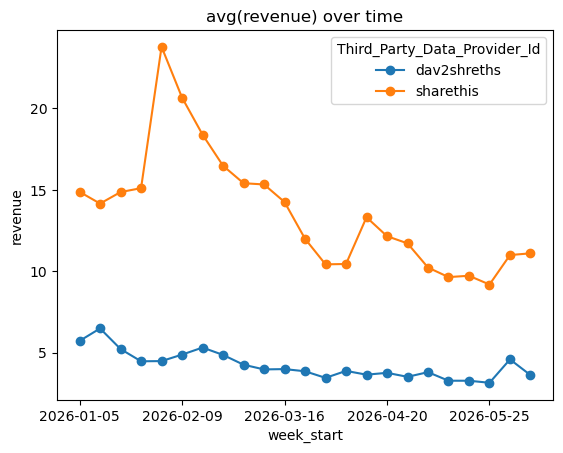

In [26]:
get_split_means(dat1, value = 'Data_Cost').plot(marker='o', title='avg(revenue) over time', ylabel='revenue')

<Axes: xlabel='week_start'>

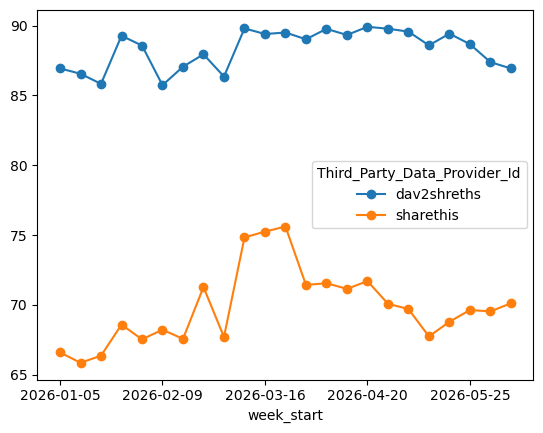

In [27]:
get_split_means(dat1, value = 'Avg_Relevance_Percentile').plot(marker='o')

## filter out bad rows

In [28]:
#dat1.head()

In [29]:
dat2 = dat1[dat1.Received_ID_Count > 0]

# also filter out rows not belonging to pricing experiment
dat2 = dat2[~dat2.group.isna()]

# Model

In [30]:
yr = dat2['Avg_Relevance_Percentile'] #['Avg_Relevance']
yd = dat2['Data_Cost'].astype(float) 

In [31]:
#seg_col = 'segment_last'
seg_col = 'segment_2'
#seg_col = 'Full_Path'

In [32]:
x_c_cols = list(dict.fromkeys([seg_col, 'week_start', 'Advertiser_Category', 'Third_Party_Data_Provider_Id', 'geo', 'segment_2']))
x_n_cols = ['Received_ID_Count', 'price', 'Avg_Relevance_Percentile'] #[ 'Active_ID_Count_Percentile', 'Paid_Pct_Percentile']
# 'Avg_Value_Percentile' has NAs

In [33]:
Xn = pd.DataFrame(dat2[x_n_cols], dtype=float)
Xn['log_Received_ID_Count'] = Xn['Received_ID_Count'].apply(lambda x: np.log(x))
x_n_cols += ['log_Received_ID_Count']

In [34]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xn = pd.DataFrame(sc.fit_transform(Xn), columns=Xn.columns, index=Xn.index)

In [35]:
Xc = pd.get_dummies(dat2[x_c_cols])

In [36]:
X = Xn.join(Xc)
X.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,log_Received_ID_Count,segment_2_arts&entertainment,segment_2_automotive,segment_2_autos&vehicles,segment_2_beauty&fitness,segment_2_books&literature,segment_2_business&finance,...,week_start_2026-05-04,week_start_2026-05-11,week_start_2026-05-18,week_start_2026-05-25,week_start_2026-06-01,week_start_2026-06-08,Advertiser_Category_All,Third_Party_Data_Provider_Id_dav2shreths,Third_Party_Data_Provider_Id_sharethis,geo_Global
78,-0.821955,0.353759,0.371469,-0.440450,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
88,-0.368923,0.353759,0.546917,0.122446,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
208,-0.904071,0.353759,0.706416,-0.597399,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
297,-1.236747,0.353759,0.594767,-2.006720,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
312,-1.309431,0.353759,0.722366,-3.916418,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True


# Revenue model

## Ridge

In [37]:
from sklearn.linear_model import Ridge

mod_d = Ridge(alpha=0.000001)
mod_d.fit(X, yd)
mod_d.score(X, yd)

0.02502715924198251

In [38]:
coef_d = pd.DataFrame(mod_d.coef_, index=X.columns, columns=['beta'])
coef_d['abs_beta'] = coef_d['beta'].abs()
coef_d_sorted = coef_d.sort_values('abs_beta', ascending=False)

In [39]:
coef_d_sorted[coef_d_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_2_people&society,71.364737,71.364737
segment_2_travel,44.985435,44.985435
segment_2_validateddemographic,41.836053,41.836053
segment_2_demographic,39.259920,39.259920
segment_2_law&government,16.561890,16.561890
segment_2_business&finance,15.083711,15.083711
segment_2_realestate,13.973694,13.973694
segment_2_health&wellness,6.055458,6.055458
segment_2_career&jobs,5.622779,5.622779
segment_2_hobbies&leisure,5.588705,5.588705


### some interesting betas

In [40]:
coef_d.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,6.831143,6.831143
log_Received_ID_Count,3.747449,3.747449


In [41]:
coef_d.filter(regex='Rel', axis='index')

,beta,abs_beta
Avg_Relevance_Percentile,2.782753,2.782753


In [42]:
coef_d.filter(regex='price', axis='index')

,beta,abs_beta
price,-0.620705,0.620705


In [43]:
coef_d.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_Global,0.0,0.0


In [44]:
coef_d.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,-2.904367,2.904367
Third_Party_Data_Provider_Id_sharethis,2.904368,2.904368


In [45]:
import matplotlib.pyplot as plt

def dfScatter(df, xcol='beta', ycol='Received_ID_Count', catcol='criterion', logx=False, logy=False):
    #fig, ax = plt.subplots()
    categories = np.unique(df[catcol])
    colors = np.linspace(0, 1, len(categories))
    colordict = dict(zip(categories, colors))  
    colors = df[catcol].apply(lambda x: colordict[x])
    return df.plot(kind='scatter', x=xcol, y=ycol, logy=logy, logx=logx, c=colors)

# RF to forecast demand curves

In [46]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [47]:
X_rf = X[X.columns[X.columns != 'log_Received_ID_Count']]

In [48]:
mod_d_rf = RFR(max_depth=5)
mod_d_rf.fit(X_rf, yd)
mod_d_rf.score(X_rf, yd)

0.3210945529542777

In [49]:
coef_d_rf = pd.DataFrame(mod_d_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_d_rf_sorted = coef_d_rf.sort_values('feature_importance', ascending=False)
coef_d_rf_sorted.head(20)

,feature_importance
Received_ID_Count,0.522795
Avg_Relevance_Percentile,0.272388
week_start_2026-02-02,0.034674
week_start_2026-02-09,0.027413
week_start_2026-02-16,0.027001
segment_2_travel,0.022200
segment_2_people&society,0.017840
week_start_2026-01-05,0.009934
week_start_2026-02-23,0.007557
week_start_2026-01-19,0.007443


In [50]:
def sweep_forecast(X_rf, mod, sc, 
                   vary_feature, grid_unscaled, 
                   n_rows=1000,
                   geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
                  ):
    """
    Sweep vary_feature across grid_unscaled, averaging revenue over n_rows real data rows.

    vary_feature : numeric feature name in sc.feature_names_in_
                   e.g. 'Received_ID_Count', 'price', 'Avg_Relevance_Percentile'
    grid_unscaled: array of raw (unscaled) values to sweep over
    n_rows       : number of real data rows to average over

    Returns DataFrame with columns: [vary_feature + '_unscaled', 'geo', 'revenue_forecast']
    """
    grid_unscaled = np.asarray(grid_unscaled)
    feat_idx = list(sc.feature_names_in_).index(vary_feature)
    grid_scaled = (grid_unscaled - sc.mean_[feat_idx]) / sc.scale_[feat_idx]

    X_rf2 = X_rf[X_rf.columns[X_rf.columns != vary_feature]]
    
    forecast_list = []
    for idx in range(min(n_rows, len(X_rf2))):
        samples_vary = pd.DataFrame(
            {vary_feature: grid_scaled},
            index=[X_rf2.index[idx]] * len(grid_scaled)
        )
        temp = samples_vary.join(X_rf2.iloc[[idx]])
        forecast_list.append(temp)

    fc = pd.concat(forecast_list)
    fc['revenue_forecast'] = mod.predict(fc[X_rf.columns])
    fc[vary_feature + '_unscaled'] = fc[vary_feature] * sc.scale_[feat_idx] + sc.mean_[feat_idx]
    fc['geo'] = fc.reindex(columns=geos).apply(
        lambda x: next((g.split('_')[1] for g in geos if x[g] == 1), 'Unknown'), axis=1
    )

    return fc.groupby(['geo', vary_feature + '_unscaled'])[['revenue_forecast']].mean().reset_index()


In [51]:
def extract_geo(x, geos):
    for geo in geos:
        if x[geo] == 1:
            return geo.split('_')[1]
    return "Unknown"

geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']


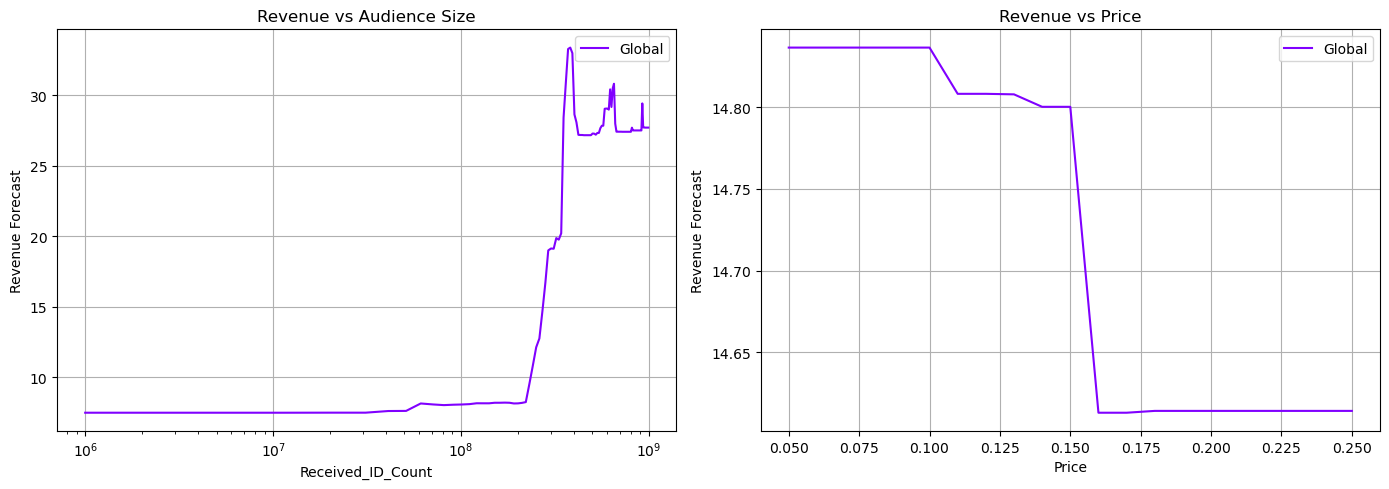

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Size sweep ---
size_grid = np.arange(1, 1000, 10) * 1_000_000
fc_size = sweep_forecast(X_rf, mod_d_rf, sc, 'Received_ID_Count', size_grid)
geos = fc_size['geo'].unique()
color = plt.cm.rainbow(np.linspace(0, 1, len(geos)))
for i, geo in enumerate(geos):
    sub = fc_size[fc_size['geo'] == geo]
    axes[0].plot(sub['Received_ID_Count_unscaled'], sub['revenue_forecast'], label=geo, color=color[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('Received_ID_Count')
axes[0].set_ylabel('Revenue Forecast')
axes[0].set_title('Revenue vs Audience Size')
axes[0].legend()
axes[0].grid(True)

# --- Price sweep ---
price_grid = np.arange(0.05, 0.26, 0.01)
fc_price = sweep_forecast(X_rf, mod_d_rf, sc, 'price', price_grid)
geos_p = fc_price['geo'].unique()
color_p = plt.cm.rainbow(np.linspace(0, 1, len(geos_p)))
for i, geo in enumerate(geos_p):
    sub = fc_price[fc_price['geo'] == geo]
    axes[1].plot(sub['price_unscaled'], sub['revenue_forecast'], label=geo, color=color_p[i])
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Revenue Forecast')
axes[1].set_title('Revenue vs Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## DID

In [53]:
relative = True

In [54]:
#test = dat[~dat.group.isna()] # all adv_types
test = dat1[~dat1.group.isna()]
#test = dat2[~dat2.group.isna()]
test = test[test.Week_Start_Date > test_df_start]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[['Data_Cost']].mean()

In [55]:
test_means_joined = test_means.xs(0, level='post').join(
    test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
).reset_index()
test_means_joined['chg'] = test_means_joined['Data_Cost_post'] - test_means_joined['Data_Cost_pre']
test_means_joined['chg_ratio'] = test_means_joined['chg'] / test_means_joined['Data_Cost_pre']

In [56]:
test_means_joined.groupby('delta')[['chg']].describe()

chg                                                                  \
       count      mean         std         min       25%       50%       75%   
delta                                                                          
-0.05  224.0  2.213757   39.731348 -391.640000 -0.006667  0.228333  2.712500   
 0.00  234.0  7.924865  115.426114  -50.616667 -0.392500  0.000000  0.330833   
 0.05  236.0 -3.175466   18.596606 -166.996667 -1.465000 -0.040000  0.060000   

                    
               max  
delta               
-0.05   161.540000  
 0.00  1757.960000  
 0.05    62.073333

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>]],
      dtype=object)

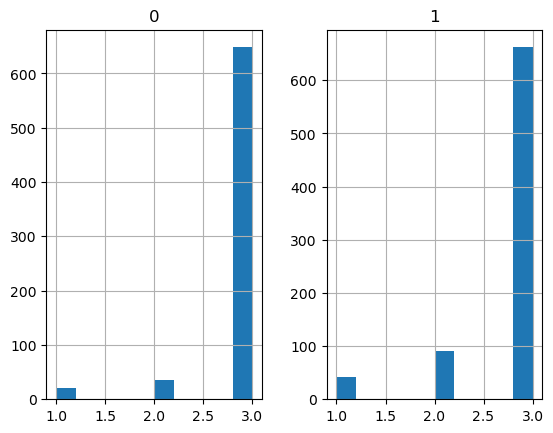

In [57]:
pd.DataFrame(test.groupby(['Full_Path','post']).size()).pivot_table(index='Full_Path', columns='post', values=0).hist()

In [58]:
import numpy as np
from scipy import stats
from scipy.stats import trim_mean as __trim_mean

# --- compute DiD ---
control_mean_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['chg']
    .mean()
    .rename('control_chg_mean')
)
did = (
    test_means_joined
    .join(control_mean_by_group, on='group')
    .dropna(subset=['control_chg_mean'])
    .copy()
)
did['did'] = did['chg'] - did['control_chg_mean']
control_level_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['Data_Cost_pre']
    .mean()
    .rename('control_level')
)
did = did.join(control_level_by_group, on='group')
did['did_rel'] = (did['did'] / did['control_level']).replace([np.inf, -np.inf], np.nan)

did_col   = 'did_rel' if relative else 'did'
did_label = 'Relative DiD  (chg / control pre-level)' if relative else 'DiD  (post−pre vs control)'

# --- shared functions ---
def ttest_trimmed(vals, trim=0.1):
    a = np.sort(vals)
    k = int(np.floor(trim * len(a)))
    return stats.ttest_1samp(a[k: len(a) - k], popmean=0)

def wilcoxon_safe(vals):
    try:
        _, p = stats.wilcoxon(vals)
        return p
    except ValueError:
        return 1.0  # all values zero — no evidence against null

def p_label(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.05:  return f'p={p:.3f}'
    return f'p={p:.3f} (n.s.)'

def desc_stats(did, col):
    rows = []
    for d in sorted(did['delta'].unique()):
        vals = did[did['delta'] == d][col].dropna().values
        _, p_t     = stats.ttest_1samp(vals, popmean=0)
        _, p_trim  = ttest_trimmed(vals)
        p_wilcox   = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta': d, 'n': len(vals),
            'mean':  round(float(vals.mean()), 3),
            'std':   round(float(vals.std()),  3),
            'cdf0':  round(float((vals <= 0).mean()), 3),
            'p5':    q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75':   q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),   # drops top/bottom 10%
            'p_wilcox': round(float(p_wilcox), 4),   # rank-based
        })
    return pd.DataFrame(rows)

def plot_did_bars(ax, did, col, metric='mean', trim=0.0):
    """One bar chart panel. metric='mean' uses trimmed-t; 'median' uses Wilcoxon."""
    deltas = sorted(did['delta'].unique())
    centers, spreads, pvals = [], [], []
    for d in deltas:
        vals = did[did['delta'] == d][col].dropna().values
        if metric == 'mean':
            _, p = ttest_trimmed(vals)
            centers.append(float(__trim_mean(vals, trim)) if trim > 0 else float(vals.mean()))
            if trim > 0:
                _k = int(np.floor(trim * len(vals)))
                _trimmed = np.sort(vals)[_k: len(vals) - _k]
                spreads.append(1.96 * float(stats.sem(_trimmed)) if len(_trimmed) > 1 else 0.0)
            else:
                spreads.append(1.96 * float(stats.sem(vals)))
        else:
            p = wilcoxon_safe(vals)
            centers.append(float(np.median(vals)))
            spreads.append((float(np.quantile(vals, 0.75)) - float(np.quantile(vals, 0.25))) / 2)
        pvals.append(float(p))
    ax.bar([str(d) for d in deltas], centers, yerr=spreads, capsize=5,
           color=['steelblue', 'brown', 'tomato'])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ylo, yhi = ax.get_ylim()
    new_yhi = yhi + (yhi - ylo) * 0.08 * len(deltas)
    ax.set_ylim(ylo, new_yhi)
    for i, (p, center, spread) in enumerate(zip(pvals, centers, spreads)):
        ax.text(i, center + spread + (new_yhi - ylo) * 0.02,
                p_label(p), ha='center', va='bottom', fontsize=8)
        # DiD estimate: annotate at bar midpoint (white inside tall bars,
        # dark just outside near-zero bars so the value is always readable)
        rng = new_yhi - ylo
        if rng > 0 and abs(center) > rng * 0.04:
            ax.text(i, center / 2, f'{center:.3g}',
                    ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color='white')
        else:
            offset = (rng * 0.02) * (1 if center >= 0 else -1)
            ax.text(i, center + offset, f'{center:.3g}',
                    ha='center', va='bottom' if center >= 0 else 'top',
                    fontsize=7.5, color='#333')
    ax.grid(axis='y', alpha=0.4)

 delta   n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 178  8.826 52.350 0.360  -5.321 -0.248   0.415 1.530 18.147 0.0261  0.0000    0.0000
  0.00 206  0.000  0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 183 -4.137 26.535 0.601 -20.164 -0.945  -0.153 0.583  9.767 0.0368  0.0037    0.0787


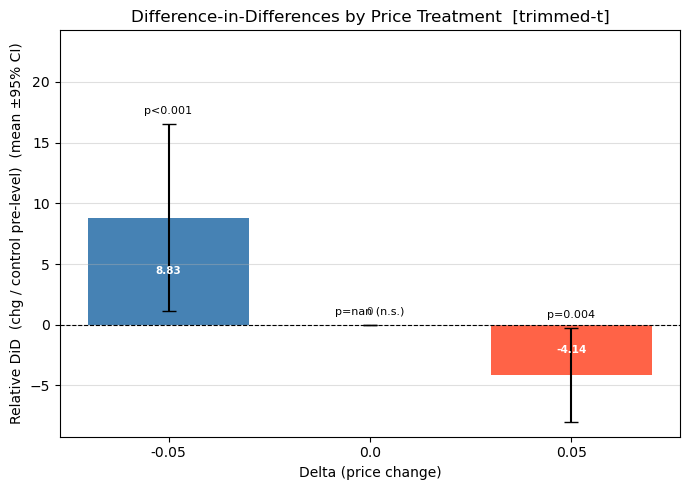

In [59]:
# --- overview: stats table + single bar chart ---
print(desc_stats(did, did_col).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
plot_did_bars(ax, did, did_col, metric='mean')
ax.set_xlabel('Delta (price change)')
ax.set_ylabel(f'{did_label}  (mean ±95% CI)')
ax.set_title('Difference-in-Differences by Price Treatment  [trimmed-t]')
plt.tight_layout()
plt.show()

=== Relative DiD  (chg / control pre-level) ===
 delta   n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 178  8.826 52.350 0.360  -5.321 -0.248   0.415 1.530 18.147 0.0261  0.0000    0.0000
  0.00 206  0.000  0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 183 -4.137 26.535 0.601 -20.164 -0.945  -0.153 0.583  9.767 0.0368  0.0037    0.0787

=== raw (chg) ===
 delta   n   mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 198  2.132  41.969 0.313  -6.152 -0.006   0.338 3.140 24.503 0.4768  0.0000    0.0000
  0.00 234  7.925 115.179 0.568  -6.471 -0.393   0.000 0.331  7.835 0.2947  0.3613    0.5335
  0.05 204 -3.652  19.916 0.676 -21.769 -1.948  -0.067 0.102  6.329 0.0097  0.0000    0.0000


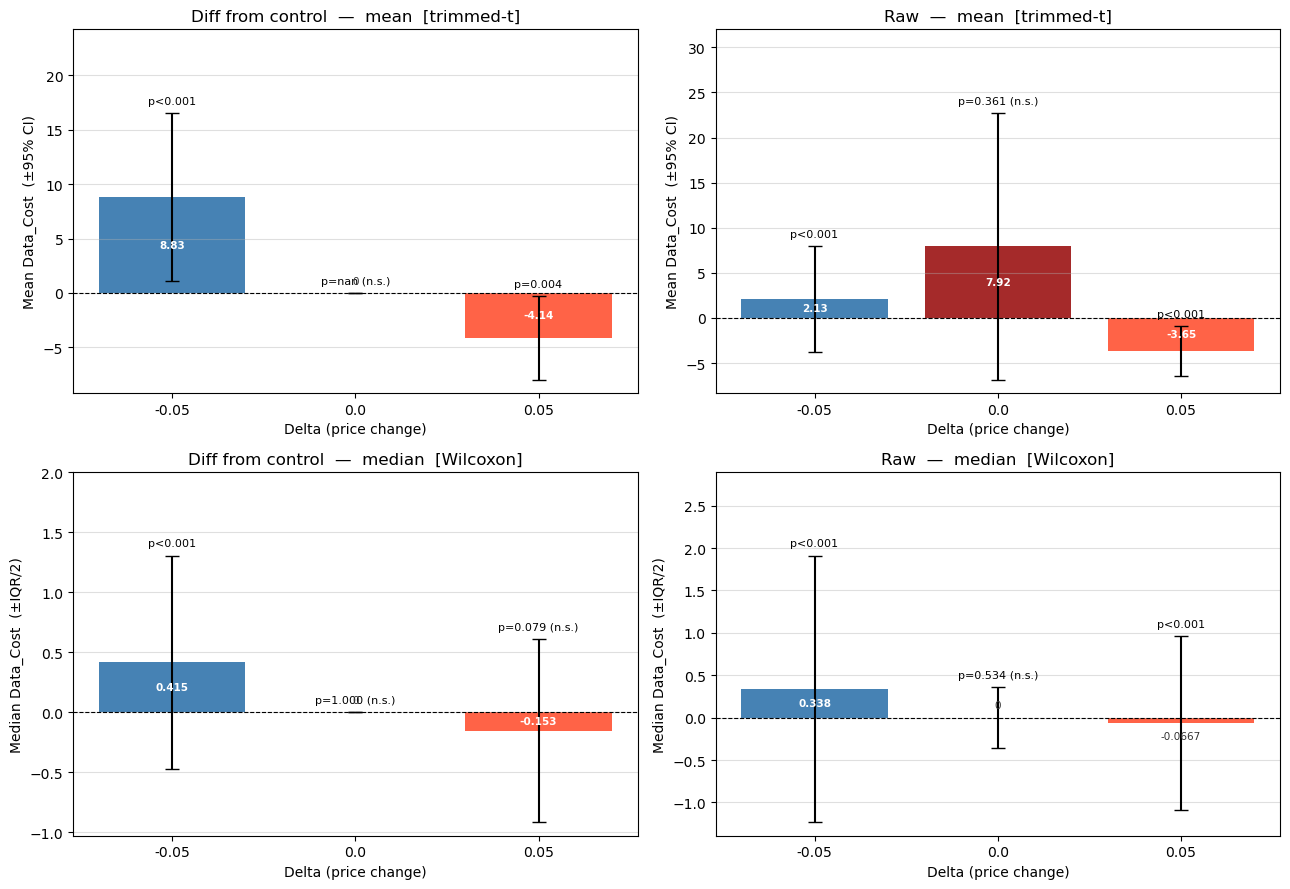

In [60]:
print(f'=== {did_label} ===')
print(desc_stats(did, did_col).to_string(index=False))
print()
print('=== raw (chg) ===')
print(desc_stats(did, 'chg').to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, metric in enumerate(['mean', 'median']):
    for col, value in enumerate(['diff from control', 'raw']):
        ax = axes[row][col]
        dcol = did_col if value == 'diff from control' else 'chg'
        spread_label = '±95% CI' if metric == 'mean' else '±IQR/2'
        p_method = 'trimmed-t' if metric == 'mean' else 'Wilcoxon'
        plot_did_bars(ax, did, dcol, metric=metric)
        ax.set_xlabel('Delta (price change)')
        ax.set_ylabel(f'{metric.capitalize()} Data_Cost  ({spread_label})')
        ax.set_title(f'{value.capitalize()}  —  {metric}  [{p_method}]')
plt.tight_layout()
plt.show()


# analysis by bucket

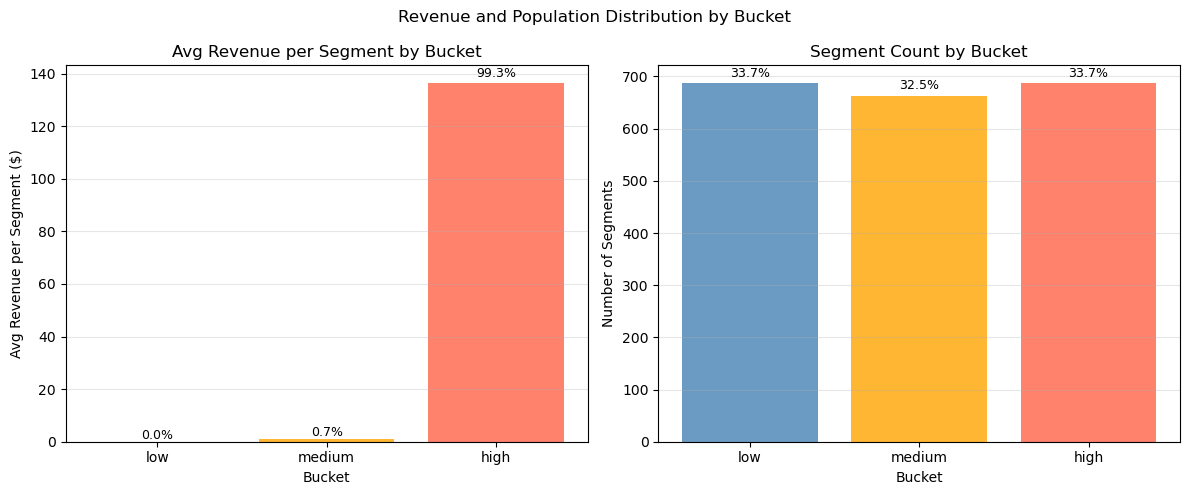

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# step 1: avg revenue per segment (Full_Path)
seg_rev = (
    pricing.groupby("Full_Path")
    .agg(revenue=("revenue", "mean"), bucket=("bucket", "first"))
)

# step 2: avg of those per-segment revenues by bucket
rev_by_bucket = seg_rev.groupby("bucket")["revenue"].mean().reindex(["low", "medium", "high"])
axes[0].bar(rev_by_bucket.index, rev_by_bucket.values, color=["steelblue", "orange", "tomato"], alpha=0.8)
axes[0].set_title("Avg Revenue per Segment by Bucket")
axes[0].set_xlabel("Bucket")
axes[0].set_ylabel("Avg Revenue per Segment ($)")
for i, v in enumerate(rev_by_bucket.values):
    pct = v / rev_by_bucket.sum() * 100
    axes[0].text(i, v * 1.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# segment count by bucket
pop_by_bucket = seg_rev.groupby("bucket").size().reindex(["low", "medium", "high"])
axes[1].bar(pop_by_bucket.index, pop_by_bucket.values, color=["steelblue", "orange", "tomato"], alpha=0.8)
axes[1].set_title("Segment Count by Bucket")
axes[1].set_xlabel("Bucket")
axes[1].set_ylabel("Number of Segments")
for i, v in enumerate(pop_by_bucket.values):
    pct = v / pop_by_bucket.sum() * 100
    axes[1].text(i, v * 1.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Revenue and Population Distribution by Bucket")
plt.tight_layout()
plt.show()

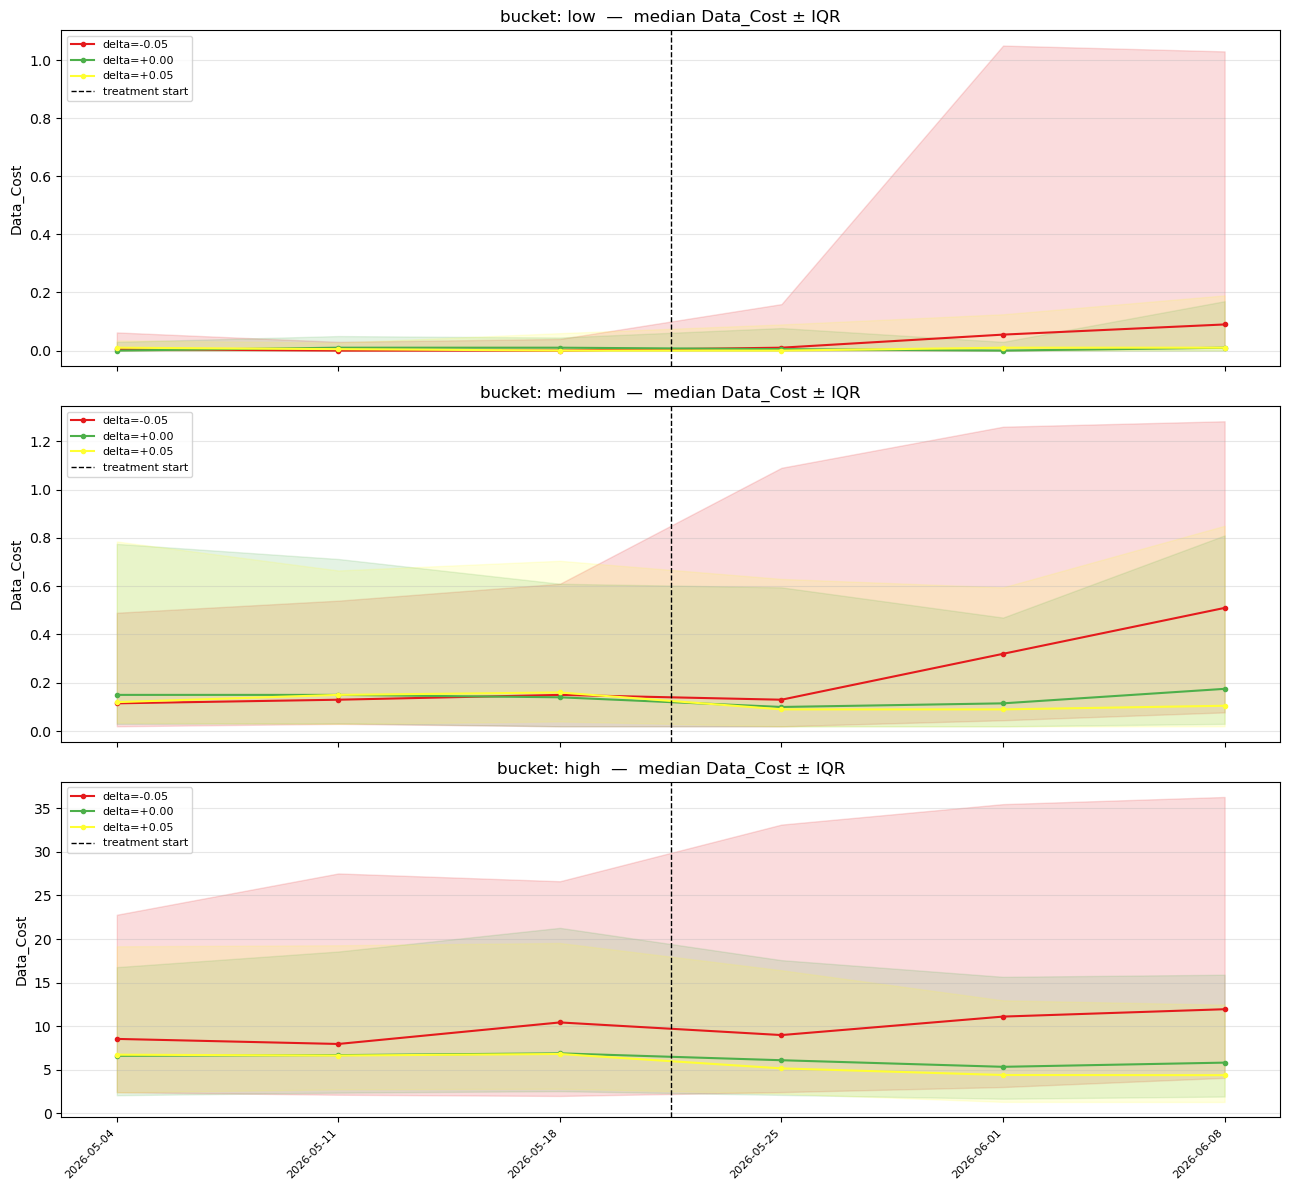

In [62]:
import matplotlib.pyplot as plt

buckets = ['low', 'medium', 'high']
delta_vals = sorted(test['delta'].unique())
dates_all = sorted(test['Week_Start_Date'].unique())
xs = list(range(len(dates_all)))
colors = plt.cm.Set1([0, 0.33, 0.66])  # one color per delta

fig, axes = plt.subplots(len(buckets), 1, figsize=(13, 4 * len(buckets)), sharex=True)

for ax, bucket in zip(axes, buckets):
    sub = test[test['bucket'] == bucket]

    for color, delta in zip(colors, delta_vals):
        grp = sub[sub['delta'] == delta].groupby('Week_Start_Date')['Data_Cost']
        medians = [grp.get_group(d).median() if d in grp.groups else np.nan for d in dates_all]
        q25     = [grp.get_group(d).quantile(0.25) if d in grp.groups else np.nan for d in dates_all]
        q75     = [grp.get_group(d).quantile(0.75) if d in grp.groups else np.nan for d in dates_all]

        ax.plot(xs, medians, marker='o', markersize=3, linewidth=1.5,
                label=f'delta={delta:+.2f}', color=color)
        ax.fill_between(xs, q25, q75, alpha=0.15, color=color)

    treat_idx = next((i for i, d in enumerate(dates_all) if str(d) > last_pre_week), None)
    if treat_idx is not None:
        ax.axvline(treat_idx - 0.5, color='black', linestyle='--', linewidth=1, label='treatment start')

    ax.set_title(f'bucket: {bucket}  —  median Data_Cost ± IQR')
    ax.set_ylabel('Data_Cost')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xticks(xs)
axes[-1].set_xticklabels([str(d)[:10] for d in dates_all], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


In [63]:
import matplotlib.ticker as mtick
import numpy as np

# join bucket from pricing into did
bucket_lookup = pricing[['Full_Path', 'bucket']].drop_duplicates().set_index('Full_Path')
did_b = did.join(bucket_lookup, on='Full_Path')
buckets = ['low', 'medium', 'high']

# extract segment_2 from Full_Path
did_b['segment_2'] = did_b['Full_Path'].apply(
    lambda x: x.lower().replace(" ", "").replace("otp>", "").split(">")[1]
    if len(x.replace(" ", "").split(">")) > 1 else "N/A"
)

# ── stats by bucket ──────────────────────────────────────────────────────────
for bucket in buckets:
    sub = did_b[did_b['bucket'] == bucket]
    print(f"=== bucket: {bucket}  (n={len(sub)}) ===")
    print(desc_stats(sub, did_col).to_string(index=False))
    print()


=== bucket: low  (n=79) ===
 delta  n    mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05  9  20.816 52.504 0.333  -0.538 -0.111   0.783 1.400 107.60 0.2947  0.2947    0.0977
  0.00 21   0.000  0.000 1.000   0.000  0.000   0.000 0.000   0.00    NaN     NaN    1.0000
  0.05  9 -18.933 40.355 0.667 -94.300 -4.333  -1.500 0.323   6.62 0.2211  0.2211    0.2500

=== bucket: medium  (n=240) ===
 delta  n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 64 13.070 72.268 0.359 -14.148 -0.150    0.56 2.037 37.290 0.1561  0.0142    0.0182
  0.00 79  0.000  0.000 1.000   0.000  0.000    0.00 0.000  0.000    NaN     NaN    1.0000
  0.05 69 -5.009 34.475 0.493 -50.877 -0.533    0.07 0.934 23.797 0.2350  0.4082    0.4276

=== bucket: high  (n=323) ===
 delta   n   mean    std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 105  5.211 34.493 0.362 -1.633 -0.358   0.352 1.105 4.932 0.1265  0.0000    0.0

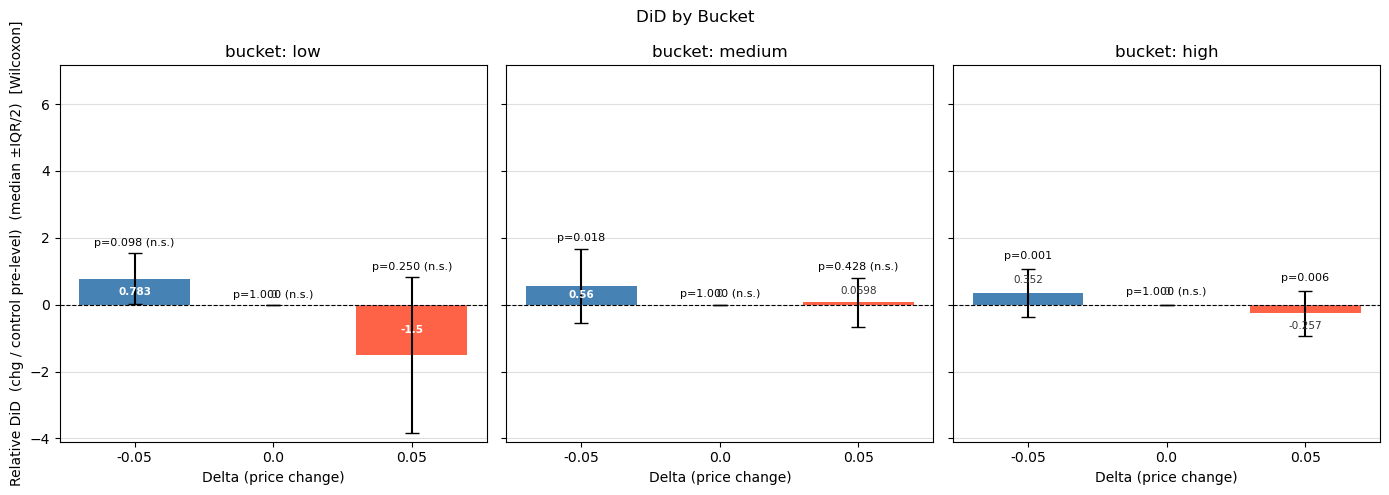

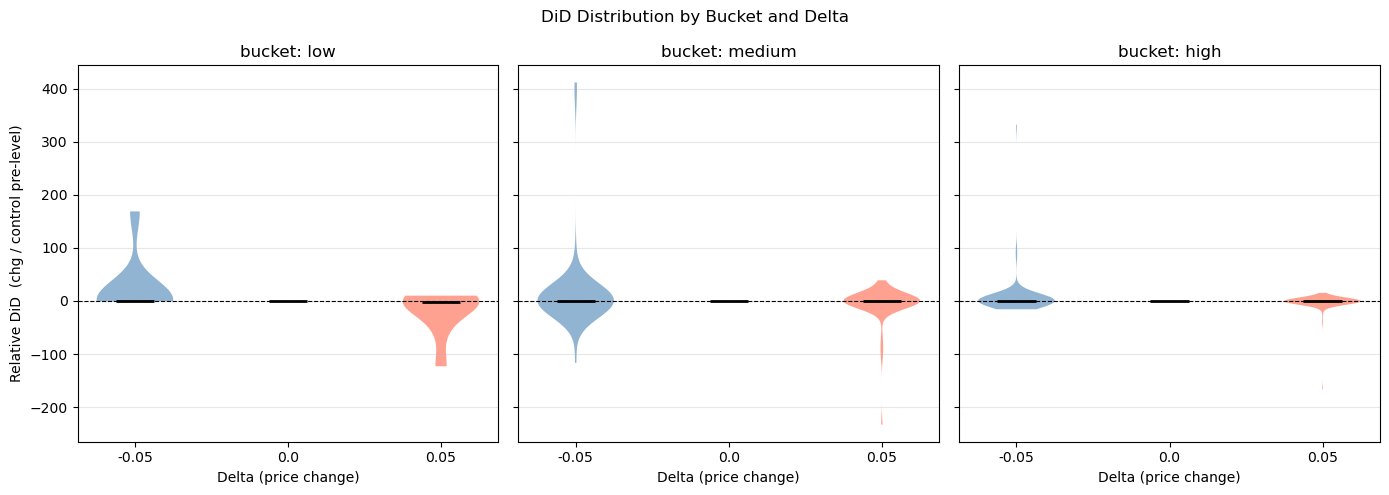

In [64]:
# ── 1. per-bucket bar charts (median DiD by delta) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, bucket in zip(axes, buckets):
    sub = did_b[did_b['bucket'] == bucket]
    plot_did_bars(ax, sub, did_col, metric='median')
    ax.set_title(f'bucket: {bucket}')
    ax.set_xlabel('Delta (price change)')
axes[0].set_ylabel(f'{did_label}  (median ±IQR/2)  [Wilcoxon]')
fig.suptitle('DiD by Bucket')
plt.tight_layout()
plt.show()

# ── 2. violin distributions by (bucket, delta) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
deltas = sorted(did_b['delta'].unique())
colors = ['steelblue', 'brown', 'tomato']

for ax, bucket in zip(axes, buckets):
    sub = did_b[did_b['bucket'] == bucket]
    data = [sub[sub['delta'] == d][did_col].dropna().values for d in deltas]
    parts = ax.violinplot(data, positions=list(range(len(deltas))),
                          showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], colors):
        body.set_facecolor(color); body.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(deltas)))
    ax.set_xticklabels([str(d) for d in deltas])
    ax.set_xlabel('Delta (price change)')
    ax.set_title(f'bucket: {bucket}')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel(did_label)
fig.suptitle('DiD Distribution by Bucket and Delta')
plt.tight_layout()
plt.show()

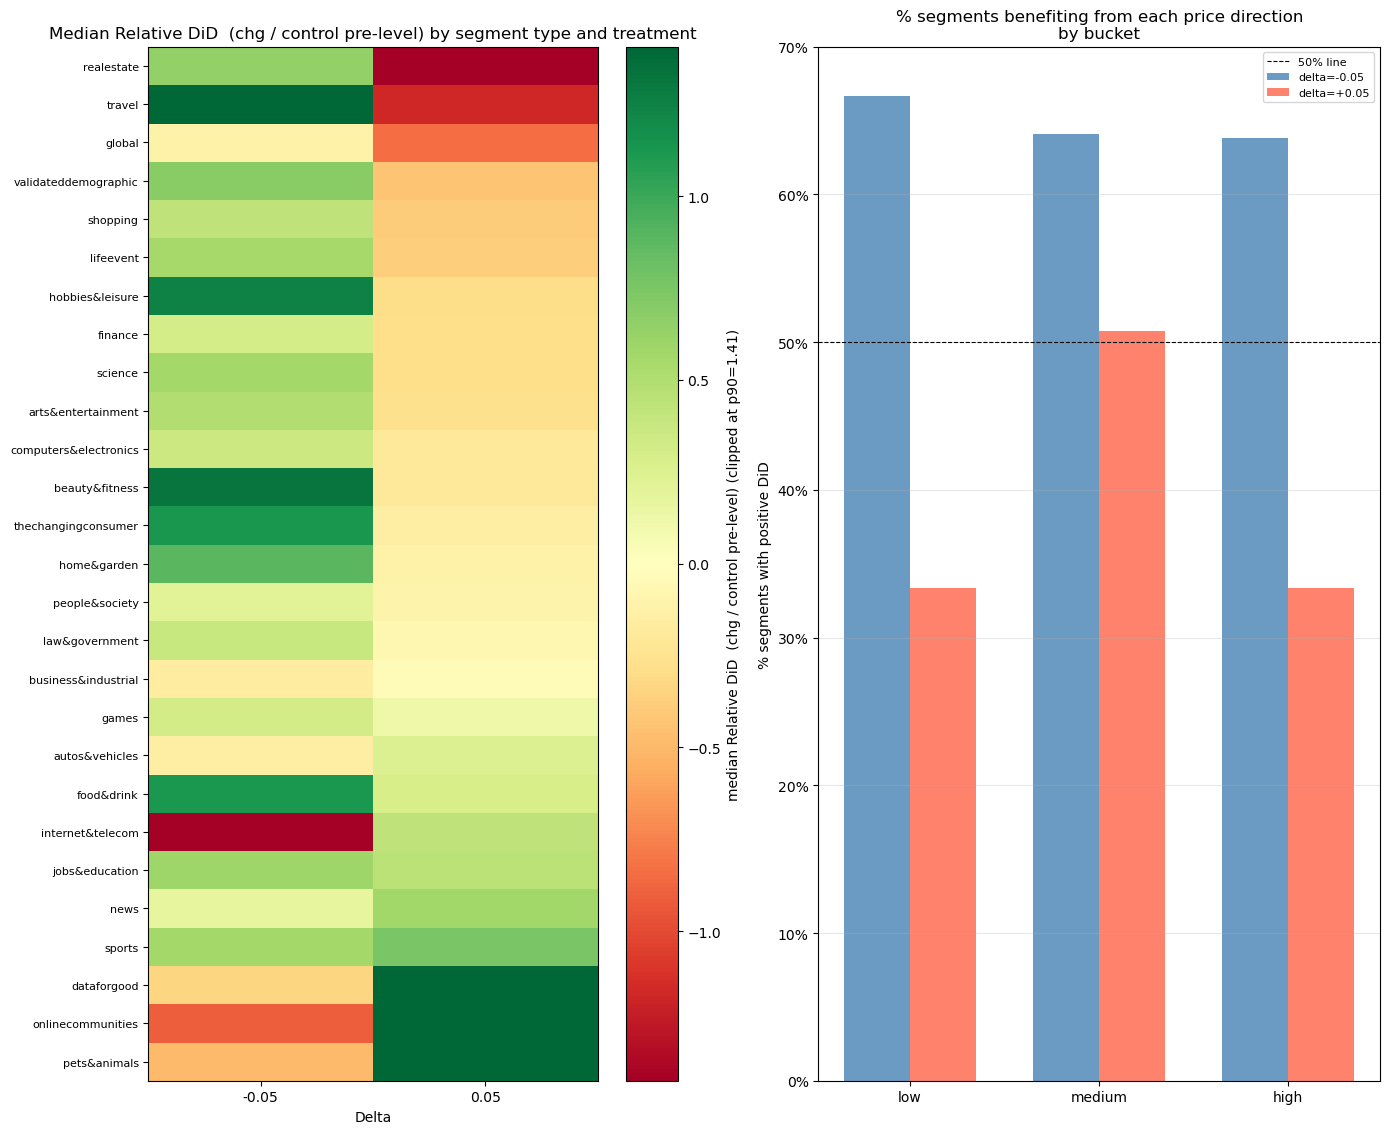

In [65]:
# segment_2 × delta median DiD (used in plots below)
# seg_col = segment_2
hm = (
    did_b[did_b['delta'] != 0]
    .groupby([seg_col, 'delta'])[did_col]
    .median()
    .unstack('delta')
    .dropna()
    .sort_values(did_b['delta'].max())
)

# ── 3. segment-type preference ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(hm) * 0.35 + 2)))

# left: heatmap — median DiD per (segment_2, delta)
vmax = np.percentile(abs(hm.values), 90)
im = axes[0].imshow(hm.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=axes[0], label=f'median {did_label} (clipped at p90={vmax:.2f})')
axes[0].set_xticks(range(len(hm.columns)))
axes[0].set_xticklabels([str(c) for c in hm.columns])
axes[0].set_yticks(range(len(hm.index)))
axes[0].set_yticklabels(hm.index, fontsize=8)
axes[0].set_xlabel('Delta')
axes[0].set_title(f'Median {did_label} by segment type and treatment')

# right: % of segments with positive DiD per (bucket, delta)
ax = axes[1]
x = np.arange(len(buckets))
width = 0.35
for di, (d, color) in enumerate(zip([-0.05, 0.05], ['steelblue', 'tomato'])):
    pcts = []
    for b in buckets:
        vals = did_b[(did_b['bucket'] == b) & (did_b['delta'] == d)][did_col].dropna()
        pcts.append((vals > 0).mean() * 100 if len(vals) > 0 else 0)
    ax.bar(x + di * width, pcts, width, label=f'delta={d:+.2f}', color=color, alpha=0.8)
ax.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(buckets)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% segments with positive DiD')
ax.set_title('% segments benefiting from each price direction\nby bucket')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [66]:
# ─── Full revenue pool — segment weights ──────────────────────────────────────
# Ranked_by_Revenue gives the experiment candidate universe.
# We use it only for relative weights (revenue share per segment), so the
# time scale of this file (March monthly) does not affect the extrapolation.

ttd_path = '/Users/ravirajan/Projects/TTD'
in_p = f"{ttd_path}/Ranked_by_Revenue.csv"

rev_pool = pd.read_csv(in_p)
rev_pool_st = rev_pool[rev_pool['Third_Party_Data_Provider_Id'] == 'sharethis'].copy()

total_pool_revenue = rev_pool_st['revenue'].sum()
rev_pool_st['pool_weight'] = rev_pool_st['revenue'] / total_pool_revenue

print(f"Sharethis segments in full pool: {len(rev_pool_st):,}")
print(f"Pool revenue (March, for weight computation only): ${total_pool_revenue:,.0f}")
print(f"Experiment segments covered: {pricing['Full_Path'].isin(rev_pool_st['Full_Path']).sum()} "
      f"of {len(rev_pool_st):,} "
      f"({pricing['Full_Path'].isin(rev_pool_st['Full_Path']).mean()*100:.1f}% of pool)")

Sharethis segments in full pool: 3,580
Pool revenue (March, for weight computation only): $181,022
Experiment segments covered: 957 of 3,580 (47.0% of pool)


In [67]:
rev_pool.groupby('Third_Party_Data_Provider_Id')['revenue'].sum()

Third_Party_Data_Provider_Id
dav2shreths     25433.86
sharethis      181021.59
Name: revenue, dtype: float64

In [68]:
rev_pool.head()

,Third_Party_Data_Provider_Id,Full_Path,revenue,rev_rank
0,sharethis,Global > people & society > social issues & ad...,13214.33,1
1,sharethis,B2B > Industry > Food Services,10172.36,2
2,sharethis,US > Health Interest > Dry Eyes,9899.08,3
3,sharethis,US > shopping > apparel > footwear,6607.92,4
4,sharethis,Global > Validated Demographic > Age > 18-44,3901.50,5


Revenue by geo × provider  (Ranked_by_Revenue, March — full candidate universe)
                 dav2shreths       sharethis         total   % of all
──────────────────────────────────────────────────────────────────────
  Global              25,433          69,417        94,850      45.9%
  US                       0          82,045        82,045      39.7%
  Unknown                  0          21,625        21,625      10.5%
  APAC                     0           4,716         4,716       2.3%
  Asia                     1           3,219         3,220       1.6%
──────────────────────────────────────────────────────────────────────
  total               25,434         181,022       206,455   100.0%

  ── ATE estimation scope ──
  Global sharethis  : $69,417
    33.6% of all revenue  (all providers, all geos)
    38.3% of total sharethis revenue

  Segment counts by geo × provider:
Third_Party_Data_Provider_Id  dav2shreths  sharethis
geo                                                

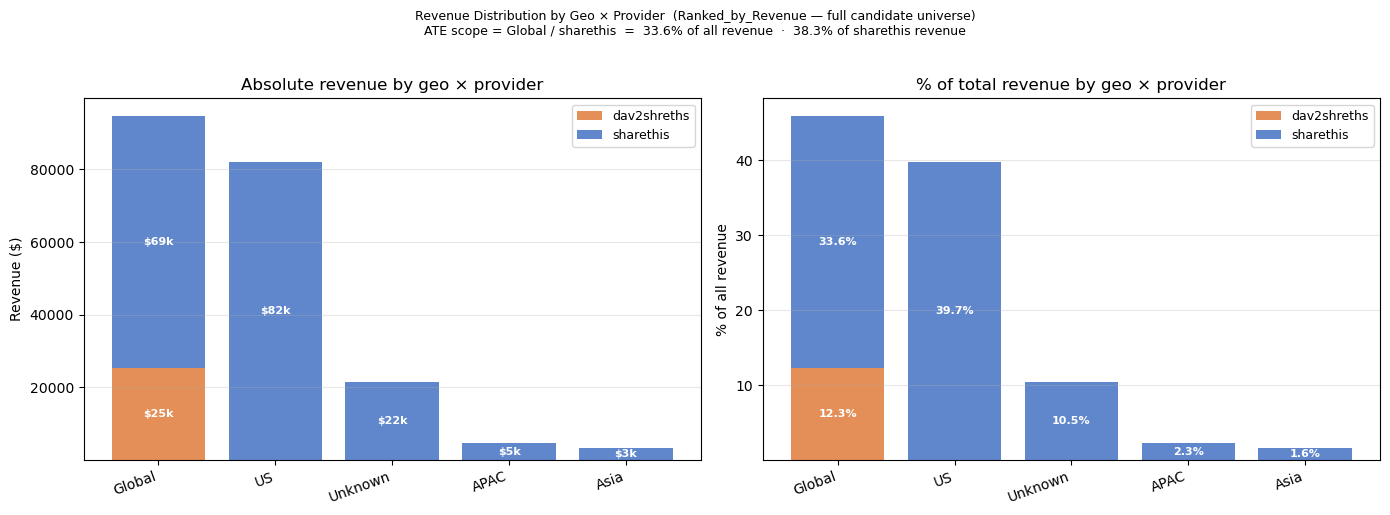

In [69]:

# ─── Revenue distribution by Geo × Provider (Ranked_by_Revenue — full universe) ─
# Shows what fraction of the total addressable revenue sits in each geo/provider
# cell — the baseline for understanding how representative the Global experiment is.

rev_pool_geo = rev_pool.copy()
rev_pool_geo['geo'] = rev_pool_geo['Full_Path'].apply(
    lambda x: get_geo(x.replace(" ", "").split(">"))
)

rev_by_gp = (
    rev_pool_geo.groupby(['geo', 'Third_Party_Data_Provider_Id'])['revenue']
    .sum()
    .unstack('Third_Party_Data_Provider_Id')
    .fillna(0)
)
rev_by_gp = rev_by_gp.loc[rev_by_gp.sum(axis=1).sort_values(ascending=False).index]

total_rev_all = rev_pool_geo['revenue'].sum()
total_rev_st  = rev_pool_st['revenue'].sum()
provs         = list(rev_by_gp.columns)
geos_rev      = list(rev_by_gp.index)

# Global sharethis specifically
global_st_rev = rev_pool_geo[
    (rev_pool_geo['geo'] == 'Global') &
    (rev_pool_geo['Third_Party_Data_Provider_Id'] == 'sharethis')
]['revenue'].sum()

print("Revenue by geo × provider  (Ranked_by_Revenue, March — full candidate universe)")
print(f"{'':12s}" + "".join(f"{c:>16s}" for c in provs) + f"{'total':>14s}  {'% of all':>9s}")
print("─" * (14 + 16 * len(provs) + 14 + 10))
for geo in geos_rev:
    row = rev_by_gp.loc[geo]
    tot = row.sum()
    print(f"  {geo:10s}" + "".join(f"{v:>16,.0f}" for v in row.values)
          + f"  {tot:>12,.0f}  {tot/total_rev_all*100:>8.1f}%")
print("─" * (14 + 16 * len(provs) + 14 + 10))
totals = rev_by_gp.sum()
print(f"  {'total':10s}" + "".join(f"{v:>16,.0f}" for v in totals.values)
      + f"  {total_rev_all:>12,.0f}   100.0%")

print(f"\n  ── ATE estimation scope ──")
print(f"  Global sharethis  : ${global_st_rev:,.0f}")
print(f"    {global_st_rev/total_rev_all*100:.1f}% of all revenue  (all providers, all geos)")
print(f"    {global_st_rev/total_rev_st*100:.1f}% of total sharethis revenue")
print(f"\n  Segment counts by geo × provider:")
seg_counts = (
    rev_pool_geo.groupby(['geo', 'Third_Party_Data_Provider_Id']).size()
    .unstack(fill_value=0)
    .loc[geos_rev]
)
print(seg_counts.to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_rev     = np.arange(len(geos_rev))
pcolors   = {'sharethis': '#4472C4', 'dav2shreths': '#E07B39'}

for ax_idx, (use_pct, ylabel, title) in enumerate([
    (False, 'Revenue ($)',       'Absolute revenue by geo × provider'),
    (True,  '% of all revenue', '% of total revenue by geo × provider'),
]):
    ax   = axes[ax_idx]
    data = rev_by_gp / (total_rev_all / 100) if use_pct else rev_by_gp
    bot  = np.zeros(len(geos_rev))
    for prov in provs:
        vals = data[prov].values
        ax.bar(x_rev, vals, bottom=bot, label=prov,
               color=pcolors.get(prov, 'gray'), alpha=0.85)
        for i, (v, b) in enumerate(zip(vals, bot)):
            thresh = 1.5 if use_pct else total_rev_all * 0.015
            if v > thresh:
                lbl = f'{v:.1f}%' if use_pct else f'${v/1000:.0f}k'
                ax.text(i, b + v / 2, lbl, ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bot += vals
    ax.set_xticks(x_rev)
    ax.set_xticklabels(geos_rev, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Revenue Distribution by Geo × Provider  (Ranked_by_Revenue — full candidate universe)\n'
    f'ATE scope = Global / sharethis  =  {global_st_rev/total_rev_all*100:.1f}% of all revenue  ·  '
    f'{global_st_rev/total_rev_st*100:.1f}% of sharethis revenue',
    fontsize=9, y=1.02
)
plt.tight_layout()
plt.show()


## Portfolio revenue impact — extrapolation logic

The experiment only covers a subset of sharethis segments. To estimate what a price change would do to **total** revenue if applied across the full universe, we extrapolate in three steps:

**Step 1 — Segment importance weights** (from `Ranked_by_Revenue`)  
Each segment gets a weight equal to its share of total sharethis revenue:  
`pool_weight_i = revenue_i / Σ revenue`  
These are pure fractions (they sum to 1). The time scale of the file (March) is irrelevant — only the relative ranking matters.

**Step 2 — Revenue-weighted mean DiD** (within experiment segments)  
For each price delta, we compute a revenue-weighted average of the estimated treatment effect:  
`wtd_mean_did_rel = Σ(pool_weight_i × did_rel_i) / Σ(pool_weight_i)`  
The denominator sums only over experiment segments (renormalized). This re-weights the average so that high-revenue segments — which contribute more to total revenue — have proportionally more influence on the estimate. Non-experiment segments are assumed to respond at this same weighted-mean rate.

**Step 3 — Scale to full universe using panel revenue**  
`extrapolated_weekly_impact = wtd_mean_did_rel × total_panel_weekly_rev`  
`total_panel_weekly_rev` is the mean weekly sum of `Data_Cost` for all sharethis segments in the **pre-period panel** — so the dollar scale is in the panel's own time units (weekly), with no dependence on the Ranked_by_Revenue file's time scale.

**Key assumption:** experiment segments are representative of the full pool in terms of how they respond to price changes. The `pool_weight_covered` column shows what fraction of the universe's total revenue weight the experiment actually covered — the lower this is, the more the extrapolation leans on that assumption.

── Step 2: Panel revenue baseline (Global sharethis only) ───────────────
  Scope          : Global / sharethis  (experiment-eligible geo only)
  Pre-period wks : 20
  Weekly range   : $17,285 – $56,834
  Mean wkly rev  : $29,336  ← dollar scale for extrapolation
  All sharethis  : $71,937/wk    →  Global is 40.8% of all sharethis panel revenue

── Step 3: Revenue-weighted DiD → extrapolated weekly impact ────────────
  Formula : extrapolated_wkly_$ = wtd_mean_did_rel × $29,336
  Scope   : Global sharethis  (40.8% of all sharethis panel revenue)

       n_segments  pool_weight_covered  unwtd_mean_did_rel  wtd_mean_did_rel  extrapolated_wkly_$
delta                                                                                            
-0.05       200.0               0.1124              8.8256            6.4767          190000.8111
 0.00       234.0               0.1048              0.0000            0.0000               0.0000
 0.05       208.0               0.1603             -4.1

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_748/3027451255.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_delta = did_impact.groupby('delta').apply(wtd_did_agg)
/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_748/3027451255.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: (df['did_rel'] * df['pool_weight'].fillna(0)).sum() /


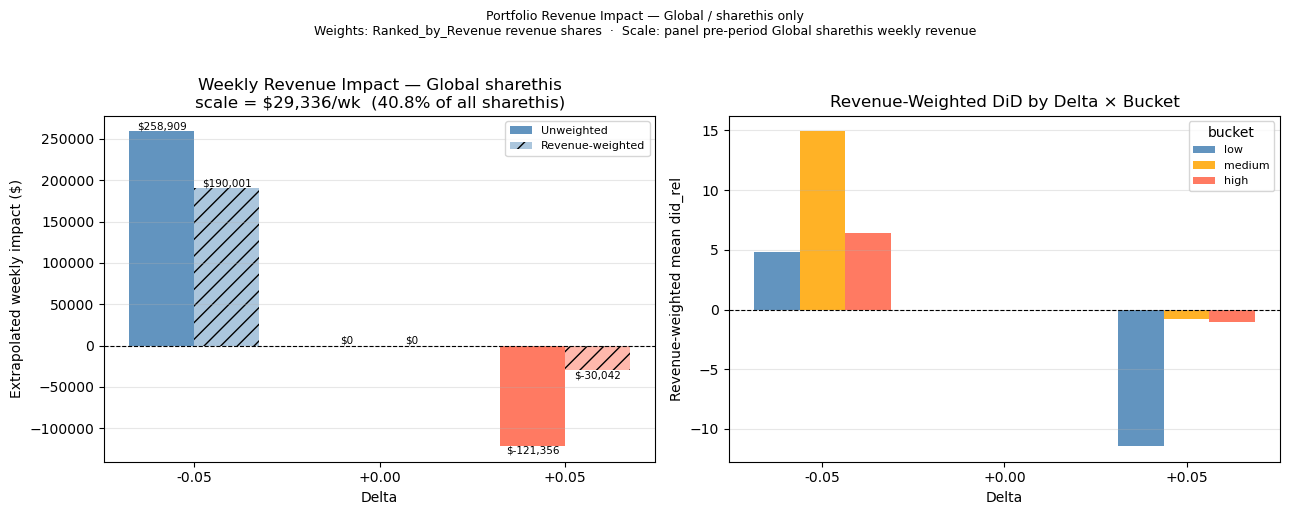

In [70]:

# ─── Portfolio-level total revenue impact ─────────────────────────────────────
# Weights: Ranked_by_Revenue revenue shares (time-scale independent fractions).
# Dollar scale: panel pre-period weekly Data_Cost for Global sharethis only,
# since the experiment (and ATE) only applies to Global geo segments.

# ── step 1: segment weights from full universe ─────────────────────────────────
seg_weights = rev_pool_st.set_index('Full_Path')['pool_weight']

bucket_lookup = (
    pricing[pricing['Third_Party_Data_Provider_Id'] == 'sharethis']
    .drop_duplicates('Full_Path')
    .set_index('Full_Path')['bucket']
)
did_impact = did.copy()
did_impact['pool_weight'] = did_impact['Full_Path'].map(seg_weights)
did_impact['bucket']      = did_impact['Full_Path'].map(bucket_lookup)

# ── step 2: Global sharethis weekly revenue baseline ──────────────────────────
# Scoped to Global only — the price change is only applied to Global segments.
pre_weeks_global = dat[
    (dat['Third_Party_Data_Provider_Id'] == 'sharethis') &
    (dat['geo'] == 'Global') &
    (dat['post'] == 0)
]
weekly_rev_global = (
    pre_weeks_global[pre_weeks_global['Data_Cost'].notna()]
    .groupby('week_start')['Data_Cost'].sum()
)
total_panel_weekly_rev = weekly_rev_global.mean()
n_pre_weeks            = weekly_rev_global.count()

# For context: all sharethis (to show what Global represents)
pre_weeks_all_st   = dat[(dat['Third_Party_Data_Provider_Id'] == 'sharethis') & (dat['post'] == 0)]
weekly_rev_all_st  = pre_weeks_all_st[pre_weeks_all_st['Data_Cost'].notna()].groupby('week_start')['Data_Cost'].sum()
total_panel_rev_st = weekly_rev_all_st.mean()

print("── Step 2: Panel revenue baseline (Global sharethis only) ───────────────")
print(f"  Scope          : Global / sharethis  (experiment-eligible geo only)")
print(f"  Pre-period wks : {n_pre_weeks}")
print(f"  Weekly range   : ${weekly_rev_global.min():,.0f} – ${weekly_rev_global.max():,.0f}")
print(f"  Mean wkly rev  : ${total_panel_weekly_rev:,.0f}  ← dollar scale for extrapolation")
print(f"  All sharethis  : ${total_panel_rev_st:,.0f}/wk  "
      f"  →  Global is {total_panel_weekly_rev/total_panel_rev_st*100:.1f}% of all sharethis panel revenue")

# ── step 3: revenue-weighted mean did_rel per delta ───────────────────────────
def wtd_did_agg(df):
    w        = df['pool_weight'].fillna(0)
    total_w  = w.sum()
    wtd_mean = (df['did_rel'] * w).sum() / total_w if total_w > 0 else np.nan
    return pd.Series({
        'n_segments'          : len(df),
        'pool_weight_covered' : round(total_w, 4),
        'unwtd_mean_did_rel'  : df['did_rel'].mean(),
        'wtd_mean_did_rel'    : wtd_mean,
        'extrapolated_wkly_$' : wtd_mean * total_panel_weekly_rev,
    })

by_delta = did_impact.groupby('delta').apply(wtd_did_agg)

print("\n── Step 3: Revenue-weighted DiD → extrapolated weekly impact ────────────")
print(f"  Formula : extrapolated_wkly_$ = wtd_mean_did_rel × ${total_panel_weekly_rev:,.0f}")
print(f"  Scope   : Global sharethis  "
      f"({total_panel_weekly_rev/total_panel_rev_st*100:.1f}% of all sharethis panel revenue)")
print()
print(by_delta.round(4).to_string())
print()
for d, row in by_delta.iterrows():
    if d == 0.0:
        continue
    direction = "price increase" if d > 0 else "price decrease"
    print(f"  delta={d:+.2f} ({direction}):  wtd_did_rel={row['wtd_mean_did_rel']:+.4f}"
          f"  →  ${row['extrapolated_wkly_$']:,.0f}/wk  "
          f"[experiment covered {row['pool_weight_covered']:.1%} of universe revenue weight]")

# bucket breakdown
by_bucket_delta = (
    did_impact.groupby(['bucket', 'delta'])
    .apply(lambda df: (df['did_rel'] * df['pool_weight'].fillna(0)).sum() /
                       df['pool_weight'].fillna(0).sum())
    .unstack('delta')
    .reindex(['low', 'medium', 'high'])
)
print("\n── Revenue-weighted mean did_rel by bucket × delta ──────────────────────")
print(by_bucket_delta.round(4).to_string())

# ── plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
deltas    = sorted(by_delta.index)
dlabels   = [f'{d:+.2f}' for d in deltas]
seg_colors= ['steelblue', '#AAAAAA', 'tomato']

x, w = np.arange(len(deltas)), 0.35
unwtd_impact = by_delta['unwtd_mean_did_rel'] * total_panel_weekly_rev
axes[0].bar(x - w/2, unwtd_impact,                    w, color=seg_colors, alpha=0.85, label='Unweighted')
axes[0].bar(x + w/2, by_delta['extrapolated_wkly_$'], w, color=seg_colors, alpha=0.45, hatch='//', label='Revenue-weighted')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xticks(x); axes[0].set_xticklabels(dlabels)
axes[0].set_xlabel('Delta'); axes[0].set_ylabel('Extrapolated weekly impact ($)')
axes[0].set_title(f'Weekly Revenue Impact — Global sharethis\n'
                  f'scale = ${total_panel_weekly_rev:,.0f}/wk  '
                  f'({total_panel_weekly_rev/total_panel_rev_st*100:.1f}% of all sharethis)')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
for i, (uw, rw) in enumerate(zip(unwtd_impact, by_delta['extrapolated_wkly_$'])):
    for v, off in [(uw, -w/2), (rw, w/2)]:
        axes[0].text(i + off, v, f'${v:,.0f}',
                     ha='center', va='bottom' if v >= 0 else 'top', fontsize=7.5)

bcols = {'low': 'steelblue', 'medium': 'orange', 'high': 'tomato'}
w3    = 0.25
for bi, b in enumerate(['low', 'medium', 'high']):
    if b in by_bucket_delta.index:
        axes[1].bar(x + (bi - 1) * w3, by_bucket_delta.loc[b], w3,
                    label=b, color=bcols[b], alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xticks(x); axes[1].set_xticklabels(dlabels)
axes[1].set_xlabel('Delta'); axes[1].set_ylabel('Revenue-weighted mean did_rel')
axes[1].set_title('Revenue-Weighted DiD by Delta × Bucket')
axes[1].legend(title='bucket', fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Portfolio Revenue Impact — Global / sharethis only\n'
    'Weights: Ranked_by_Revenue revenue shares  ·  Scale: panel pre-period Global sharethis weekly revenue',
    y=1.02, fontsize=9
)
plt.tight_layout()
plt.show()


## ATE estimation — Route 1: bucket-weighted ATT

The experiment selected only **Global** geo segments, ranked by revenue within sharethis, then grouped into buckets of 120 groups (`n=120`, 3 segments per group). The DiD gives us ATT within each bucket. To estimate ATE, we need the bucket distribution of the *full* eligible universe — all Global sharethis segments in `Ranked_by_Revenue` — and weight accordingly:

```
ATE = Σ_bucket [ P(bucket | full universe) × ATT_bucket ]
```

Two weighting schemes are shown:
- **Segment-count weights**: each bucket's share of the total eligible segment count — treats every segment equally
- **Revenue weights**: each bucket's share of total eligible revenue — gives more influence to high-revenue buckets

If the experiment over-sampled high-revenue segments relative to the universe, the experiment-average ATT will differ from the ATE, and the revenue-weighted ATE will reveal whether the bias matters for the dollar impact estimate.

  SHARETHIS UNIVERSE  (Ranked_by_Revenue -- treatable segments only)
  geo           n_segs   % ST segs     revenue   % ST rev   % all rev
  -----------------------------------------------------------------
  US               831      23.2%    $  82,045     45.3%      39.7%
  Global         1,020      28.5%    $  69,417     38.3%      33.6%  <- experiment
  Unknown          499      13.9%    $  21,625     11.9%      10.5%
  APAC              12       0.3%    $   4,716      2.6%       2.3%
  Asia           1,218      34.0%    $   3,219      1.8%       1.6%
  -----------------------------------------------------------------
  total          3,580      100.0%    $ 181,022    100.0%      87.7%

  ATE scope: Global only  (1,020 segs, 28.5% of ST segs, 38.3% of ST rev)
  Panel $/wk (Global ST): $29,336

Global ST bucket distribution  (n=1020 universe segs, pricing one-delta slice):
        n_segs  seg_wt
bucket                
high       218  0.3417
medium     200  0.3135
low        220  0.3

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_748/2174746851.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ('trimmed mean', 'trim',   'att', att_trim   if False else did_sub.groupby('delta').apply(lambda x: trim_mean(x['did'].dropna().values, TRIM))),
/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_748/2174746851.py:135: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ('median'

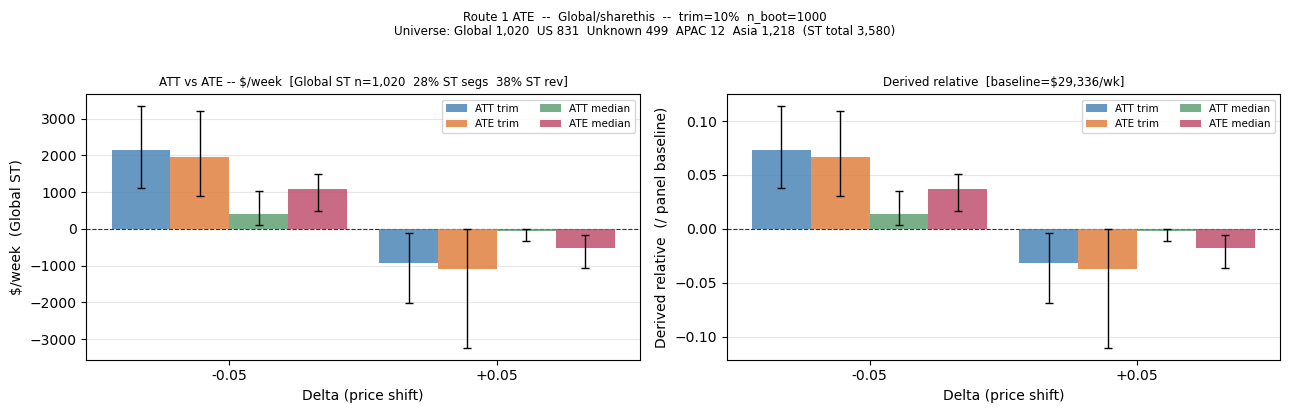

In [71]:
# Route 1 ATE: bucket-weighted ATT — Global / sharethis only
# ATT estimated three ways: raw mean (unstable), trimmed mean (10%), median.
# Raw mean shown for reference only — extreme outliers from near-zero control_level
# segments make it unreliable. Trimmed mean and median are the primary estimates.
#
# Formula:
#   ATT_bucket  = estimator(did) per bucket per delta         [$/seg/wk]
#   ATE         = sum_bucket  P(bucket) x ATT_bucket          [$/seg/wk]
#   total_$/wk  = ATE x n_univ
#   derived_rel = total_$/wk / total_panel_weekly_rev

from scipy.stats import trim_mean

N_BOOT = 1000
TRIM   = 0.10   # fraction trimmed from each tail
RNG    = np.random.default_rng(42)

# 1. Sharethis universe from Ranked_by_Revenue
st_rbr = rev_pool_geo[rev_pool_geo['Third_Party_Data_Provider_Id'] == 'sharethis'].copy()
geo_summary = (
    st_rbr.groupby('geo')
    .agg(n_segs=('Full_Path', 'count'), revenue=('revenue', 'sum'))
    .sort_values('revenue', ascending=False)
)
geo_summary['pct_st_segs'] = geo_summary['n_segs']  / geo_summary['n_segs'].sum()
geo_summary['pct_st_rev']  = geo_summary['revenue'] / geo_summary['revenue'].sum()
geo_summary['pct_all_rev'] = geo_summary['revenue'] / total_rev_all
total_st_segs = int(geo_summary['n_segs'].sum())
total_st_rev  = geo_summary['revenue'].sum()

print('=' * 75)
print('  SHARETHIS UNIVERSE  (Ranked_by_Revenue -- treatable segments only)')
print('=' * 75)
print(f"  {'geo':<10s}  {'n_segs':>8s}  {'% ST segs':>10s}  "
      f"{'revenue':>10s}  {'% ST rev':>9s}  {'% all rev':>10s}")
print('  ' + '-' * 65)
for geo, row in geo_summary.iterrows():
    marker = '  <- experiment' if geo == 'Global' else ''
    print(f"  {geo:<10s}  {int(row['n_segs']):>8,}  {row['pct_st_segs']:>9.1%}  "
          f"  ${row['revenue']:>8,.0f}  {row['pct_st_rev']:>8.1%}  {row['pct_all_rev']:>9.1%}" + marker)
print('  ' + '-' * 65)
print(f"  {'total':<10s}  {total_st_segs:>8,}  {'100.0%':>10s}  "
      f"  ${total_st_rev:>8,.0f}  {'100.0%':>8s}  {total_st_rev/total_rev_all:>9.1%}")
print(f"\n  ATE scope: Global only  ({int(geo_summary.loc['Global','n_segs']):,} segs, "
      f"{geo_summary.loc['Global','pct_st_segs']:.1%} of ST segs, "
      f"{geo_summary.loc['Global','pct_st_rev']:.1%} of ST rev)")
print(f"  Panel $/wk (Global ST): ${total_panel_weekly_rev:,.0f}")
print('=' * 75)

# 2. Universe bucket weights from pricing
st_global_px = pricing[
    (pricing['Third_Party_Data_Provider_Id'] == 'sharethis') &
    (pricing['geo'] == 'Global')
]
nonzero_deltas = st_global_px['delta'][st_global_px['delta'] != 0].abs().round(6)
min_delta      = nonzero_deltas.min()
one_delta_px   = st_global_px[st_global_px['delta'].abs().round(6) == min_delta]
bkts     = ['high', 'medium', 'low']
n_by_bkt = one_delta_px.groupby('bucket').size().reindex(bkts)
seg_wt   = n_by_bkt / n_by_bkt.sum()
n_univ   = int(geo_summary.loc['Global', 'n_segs'])

print(f"\nGlobal ST bucket distribution  (n={n_univ} universe segs, pricing one-delta slice):")
print(n_by_bkt.to_frame('n_segs').assign(seg_wt=seg_wt.round(4)).to_string())

# 3. ATT by bucket x delta -- three estimators
did_sub = did_impact[did_impact['bucket'].notna()].copy()
deltas_nz = sorted([d for d in did_sub['delta'].unique() if d != 0.0])

def att_table(did_sub, fn, bkts, deltas_nz):
    rows = {}
    for b in bkts:
        rows[b] = {}
        for d in deltas_nz:
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == d)]['did'].dropna().values
            rows[b][d] = fn(vals) if len(vals) > 0 else np.nan
    return pd.DataFrame(rows).T.reindex(bkts)

att_mean   = att_table(did_sub, np.mean,                           bkts, deltas_nz)
att_trim   = att_table(did_sub, lambda v: trim_mean(v, TRIM),      bkts, deltas_nz)
att_median = att_table(did_sub, np.median,                         bkts, deltas_nz)

print(f"\nATT by bucket x delta  [$/seg/wk]")
print(f"  {'':12s}" + ''.join(f"  delta={d:+.2f}" for d in deltas_nz))
for b in bkts:
    vals_sub = did_sub[did_sub['bucket'] == b]
    print(f"  {b:<10s}")
    for label, tbl in [('mean  ', att_mean), (f'trim{int(TRIM*100)}%', att_trim), ('median', att_median)]:
        row = f"    {label}  "
        for d in deltas_nz:
            v = tbl.loc[b, d]
            n = len(vals_sub[vals_sub['delta'] == d]['did'].dropna())
            row += f"  {v:>+8.4f} (n={n})  "
        print(row)

# 4. ATE point estimates -- trimmed mean and median only
def ate_from_att(att_tbl, seg_wt, deltas_nz):
    return (att_tbl[deltas_nz].T * seg_wt).T.sum(skipna=False)

ate_trim   = ate_from_att(att_trim,   seg_wt, deltas_nz)
ate_median = ate_from_att(att_median, seg_wt, deltas_nz)

# 5. Bootstrap 95% CIs
def boot_ate(did_sub, seg_wt, bkts, delta, n_boot, rng, fn):
    samples = []
    for _ in range(n_boot):
        ate_b = 0.0
        for b in bkts:
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == delta)]['did'].dropna().values
            if len(vals) == 0: continue
            ate_b += seg_wt[b] * fn(rng.choice(vals, size=len(vals), replace=True))
        samples.append(ate_b)
    return np.percentile(samples, [2.5, 97.5])

def boot_att_overall(did_sub, delta, n_boot, rng, fn):
    vals  = did_sub[did_sub['delta'] == delta]['did'].dropna().values
    boots = [fn(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])

ci = {}  # keyed by (estimator, 'att'/'ate', delta)
for d in deltas_nz:
    for est_name, fn in [('trim', lambda v: trim_mean(v, TRIM)), ('median', np.median)]:
        ci[(est_name, 'att', d)] = boot_att_overall(did_sub, d, N_BOOT, RNG, fn)
        ci[(est_name, 'ate', d)] = boot_ate(did_sub, seg_wt, bkts, d, N_BOOT, RNG, fn)

# 6. Summary table
print(f"\n{'':=>78}")
print(f"  ATE / ATT  [Global sharethis, n_univ={n_univ:,}]  --  $/seg/wk  |  $/wk total  |  derived rel")
print(f"  95% bootstrap CI  (n_boot={N_BOOT},  trim={int(TRIM*100)}%)")
print(f"{'':=>78}")

rows = [
    ('trimmed mean', 'trim',   'att', att_trim   if False else did_sub.groupby('delta').apply(lambda x: trim_mean(x['did'].dropna().values, TRIM))),
    ('trimmed mean', 'trim',   'ate', ate_trim),
    ('median',       'median', 'att', did_sub.groupby('delta').apply(lambda x: np.median(x['did'].dropna().values))),
    ('median',       'median', 'ate', ate_median),
]

# rebuild cleanly
att_trim_overall   = did_sub.groupby('delta').apply(lambda x: trim_mean(x['did'].dropna().values, TRIM))
att_median_overall = did_sub.groupby('delta').apply(lambda x: np.median(x['did'].dropna().values))

summary_rows = [
    ('ATT trimmed mean',  'trim',   'att', att_trim_overall),
    ('ATE trimmed mean',  'trim',   'ate', ate_trim),
    ('ATT median',        'median', 'att', att_median_overall),
    ('ATE median',        'median', 'ate', ate_median),
]

print(f"  {'':30s}  " + '  '.join(f"{'delta='+f'{d:+.2f}':^42s}" for d in deltas_nz))
print(f"  {'':30s}  " + '  '.join(f"{'$/seg/wk':>8s}  {'$/wk':>9s}  {'rel':>6s}  {'95% CI ($/wk)':^18s}" for _ in deltas_nz))
print(f"{'':->78}")

for label, est, kind, series in summary_rows:
    print(f"  {label:30s}", end='')
    for d in deltas_nz:
        v      = series.get(d, float('nan'))
        lo, hi = ci[(est, kind, d)]
        tot    = v  * n_univ
        rel    = tot / total_panel_weekly_rev
        tot_lo = lo * n_univ
        tot_hi = hi * n_univ
        print(f"  {v:>+8.4f}  ${tot:>8,.0f}  {rel:>+5.3f}  [{tot_lo:>+7,.0f},{tot_hi:>+7,.0f}]", end='')
    print()
    if kind == 'ate':
        print()

print(f"  Baseline: ${total_panel_weekly_rev:,.0f}/wk  (Global ST panel, pre-period)")
print(f"  rel = total_$/wk / ${total_panel_weekly_rev:,.0f}")

# 7. Extrapolation guide
print(f"\n{'':=>78}")
print(f"  Extrapolation  (ATE $/seg/wk x geo n_segs -- assumes same price elasticity)")
print(f"  Using trimmed mean ATE as primary estimate")
print(f"{'':=>78}")
print(f"  {'geo':<10s}  {'n_segs':>7s}  ", end='')
for d in deltas_nz:
    print(f" {'delta='+f'{d:+.2f}':^28s}  ", end='')
print()
print(f"  {'':10s}  {'':7s}  ", end='')
for d in deltas_nz:
    print(f"  {'trim $/wk':>12s}  {'median $/wk':>12s}  ", end='')
print()
print('  ' + '-' * 70)

for geo, row in geo_summary.iterrows():
    n    = int(row['n_segs'])
    line = f"  {geo:<10s}  {n:>7,}  "
    for d in deltas_nz:
        vt = ate_trim.get(d, float('nan'))   * n
        vm = ate_median.get(d, float('nan')) * n
        line += f"  ${vt:>10,.0f}  ${vm:>10,.0f}  "
    if geo == 'Global':
        line += ' <- estimated from experiment'
    print(line)

print('  ' + '-' * 70)
line = f"  {'all ST':<10s}  {total_st_segs:>7,}  "
for d in deltas_nz:
    vt = ate_trim.get(d, float('nan'))   * total_st_segs
    vm = ate_median.get(d, float('nan')) * total_st_segs
    line += f"  ${vt:>10,.0f}  ${vm:>10,.0f}  "
print(line)
print(f"{'':=>78}")

# 8. Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_pos   = np.arange(len(deltas_nz))
xlabels = [f'{d:+.2f}' for d in deltas_nz]
bw      = 0.22

plot_ests = [
    ('ATT trim',   'trim',   'att', att_trim_overall,   'steelblue',  -1),
    ('ATE trim',   'trim',   'ate', ate_trim,            '#E07B39',     0),
    ('ATT median', 'median', 'att', att_median_overall,  '#5A9E6F',     1),
    ('ATE median', 'median', 'ate', ate_median,          '#BE4A6A',     2),
]

global_pct_st_segs = geo_summary.loc['Global', 'pct_st_segs']
global_pct_st_rev  = geo_summary.loc['Global', 'pct_st_rev']

for ax_idx, (scale, ylabel, title_str) in enumerate([
    (n_univ,
     '$/week  (Global ST)',
     f'ATT vs ATE -- $/week  [Global ST n={n_univ:,}  '
     f'{global_pct_st_segs:.0%} ST segs  {global_pct_st_rev:.0%} ST rev]'),
    (n_univ / total_panel_weekly_rev,
     'Derived relative  (/ panel baseline)',
     f'Derived relative  [baseline=${total_panel_weekly_rev:,.0f}/wk]'),
]):
    ax = axes[ax_idx]
    offsets = np.array([-1.5, -0.5, 0.5, 1.5])
    for (label, est, kind, series, col, _), offset in zip(plot_ests, offsets):
        vals = [series.get(d, float('nan')) * scale for d in deltas_nz]
        lo_  = [(series.get(d, float('nan')) - ci[(est, kind, d)][0]) * scale for d in deltas_nz]
        hi_  = [(ci[(est, kind, d)][1] - series.get(d, float('nan'))) * scale for d in deltas_nz]
        xpos = x_pos + offset * bw
        ax.bar(xpos, vals, bw, label=label, color=col, alpha=0.82, zorder=3)
        ax.errorbar(xpos, vals, yerr=[lo_, hi_], fmt='none', color='black',
                    capsize=3, lw=1, zorder=4)
    ax.axhline(0, color='#333', lw=0.8, ls='--')
    ax.set_xticks(x_pos); ax.set_xticklabels(xlabels)
    ax.set_xlabel('Delta (price shift)'); ax.set_ylabel(ylabel)
    ax.set_title(title_str, fontsize=8.5)
    ax.legend(fontsize=7.5, ncol=2); ax.grid(axis='y', alpha=0.3)

other_geos = '  '.join(
    f'{g} {int(r["n_segs"]):,}' for g, r in geo_summary.iterrows() if g != 'Global'
)
fig.suptitle(
    f'Route 1 ATE  --  Global/sharethis  --  trim={int(TRIM*100)}%  n_boot={N_BOOT}\n'
    f'Universe: Global {int(geo_summary.loc["Global","n_segs"]):,}  '
    + other_geos + f'  (ST total {total_st_segs:,})',
    fontsize=8.5, y=1.02
)
plt.tight_layout()
plt.show()


# Impact on Impressions and eCPM

Price changes affect two demand-side signals beyond revenue:

- **`Effective_Impression_Count`** — how many impressions buyers generated from the segment. A price increase compresses demand (fewer impressions); a decrease expands it.
- **eCPM** (`Data_Cost * 1000 / Effective_Impression_Count`) — the effective cost per thousand impressions. This captures price elasticity: if buyers reduce usage by more than the price increase, eCPM can still fall.

**Method:** absolute DiD first (pre→post change minus the control group's trend), then normalized by the control group's pre-period level to produce relative (%) DiDs.


In [72]:
# ── Build DiD for Effective_Impression_Count and eCPM ─────────────────────────
# Mirrors the revenue DiD: segment-level pre/post means, then subtract the
# control group's trend to isolate the treatment effect.

# Segment × period means (averaging over weeks within each pre/post window)
vol_means = (
    test
    .groupby(['group', 'Full_Path', 'delta', 'post'])
    [['Data_Cost', 'Effective_Impression_Count']]
    .mean()
)
# eCPM at the segment × period level; EIC = 0 produces inf → replaced with NaN
vol_means['eCPM'] = (
    vol_means['Data_Cost'] * 1000 / vol_means['Effective_Impression_Count']
).replace([np.inf, -np.inf], np.nan)

# Pivot pre / post into columns
vol_pre    = vol_means.xs(0, level='post')
vol_post   = vol_means.xs(1, level='post')
vol_joined = vol_pre.join(vol_post, lsuffix='_pre', rsuffix='_post').reset_index()

# Pre→post change per segment
vol_joined['chg_eic']  = (vol_joined['Effective_Impression_Count_post']
                          - vol_joined['Effective_Impression_Count_pre'])
vol_joined['chg_ecpm'] = vol_joined['eCPM_post'] - vol_joined['eCPM_pre']

# Control group's mean trend (to subtract) and pre-level (denominator for rel DiD)
ctrl_chg = (
    vol_joined[vol_joined['delta'] == 0]
    .groupby('group')[['chg_eic', 'chg_ecpm']]
    .mean()
    .rename(columns={'chg_eic': 'ctrl_chg_eic', 'chg_ecpm': 'ctrl_chg_ecpm'})
)
ctrl_level = (
    vol_joined[vol_joined['delta'] == 0]
    .groupby('group')[['Effective_Impression_Count_pre', 'eCPM_pre']]
    .mean()
    .rename(columns={
        'Effective_Impression_Count_pre': 'ctrl_level_eic',
        'eCPM_pre':                       'ctrl_level_ecpm',
    })
)

did_vol = (
    vol_joined
    .join(ctrl_chg,   on='group')
    .join(ctrl_level, on='group')
    .dropna(subset=['ctrl_chg_eic'])
    .copy()
)

# Absolute DiD
did_vol['did_eic']  = did_vol['chg_eic']  - did_vol['ctrl_chg_eic']
did_vol['did_ecpm'] = did_vol['chg_ecpm'] - did_vol['ctrl_chg_ecpm']

# Relative DiD: absolute DiD / control pre-period level
did_vol['did_eic_rel']  = (did_vol['did_eic']  / did_vol['ctrl_level_eic'] ).replace([np.inf, -np.inf], np.nan)
did_vol['did_ecpm_rel'] = (did_vol['did_ecpm'] / did_vol['ctrl_level_ecpm']).replace([np.inf, -np.inf], np.nan)

# Bucket labels (re-derived here so this cell is self-contained)
_bucket_map = (
    pricing[pricing['Third_Party_Data_Provider_Id'] == 'sharethis']
    .drop_duplicates('Full_Path')
    .set_index('Full_Path')['bucket']
)
did_vol = did_vol.join(_bucket_map, on='Full_Path')

# Shorthand used by the summary and bucket cells below
_vol_metrics = [
    ('did_eic',  'did_eic_rel',  'Effective Impression Count'),
    ('did_ecpm', 'did_ecpm_rel', 'eCPM  (Data_Cost * 1000 / EIC)'),
]

# Revenue DiD — computed directly from vol_joined (same Data_Cost columns,
# no cross-dataframe join needed, avoids any key-matching fragility).
did_vol['chg_rev'] = did_vol['Data_Cost_post'] - did_vol['Data_Cost_pre']
ctrl_chg_rev = (
    did_vol[did_vol['delta'] == 0]
    .groupby('group')['chg_rev']
    .mean()
    .rename('ctrl_chg_rev')
)
ctrl_level_rev = (
    did_vol[did_vol['delta'] == 0]
    .groupby('group')['Data_Cost_pre']
    .mean()
    .rename('ctrl_level_rev')
)
did_vol = (
    did_vol
    .join(ctrl_chg_rev,  on='group')
    .join(ctrl_level_rev, on='group')
)
did_vol['did_rev']     = did_vol['chg_rev'] - did_vol['ctrl_chg_rev']
did_vol['did_rev_rel'] = (did_vol['did_rev'] / did_vol['ctrl_level_rev']).replace([np.inf, -np.inf], np.nan)

# Trimming fraction used throughout this section (matches the ATE analysis above)
_TRIM = 0.10
from scipy.stats import trim_mean as _trim_mean

def desc_stats_trim(df, col, trim=_TRIM):
    """Like desc_stats but uses trimmed mean as the primary point estimate."""
    rows = []
    for d in sorted(df['delta'].unique()):
        vals = df[df['delta'] == d][col].dropna().values
        _, p_t    = stats.ttest_1samp(vals, popmean=0)
        _, p_trim = ttest_trimmed(vals)
        p_wilcox  = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta':     d,
            'n':         len(vals),
            'trim_mean': round(float(_trim_mean(vals, trim)), 3),
            'std':       round(float(vals.std()), 3),
            'cdf0':      round(float((vals <= 0).mean()), 3),
            'p5':  q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75': q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),
            'p_wilcox': round(float(p_wilcox), 4),
        })
    return pd.DataFrame(rows)

_sum_cols = ['did_rev', 'did_rev_rel', 'did_eic', 'did_ecpm', 'did_eic_rel', 'did_ecpm_rel']
print(f"Segments: {len(did_vol):,}  |  eCPM computable (EIC > 0): {did_vol['did_ecpm'].notna().sum():,}")
print(f"Trimmed mean (trim={_TRIM}) by delta:")
did_vol.groupby('delta')[_sum_cols].apply(
    lambda g: g.apply(lambda c: round(_trim_mean(c.dropna().values, _TRIM), 4))
)


Segments: 642  |  eCPM computable (EIC > 0): 606
Trimmed mean (trim=0.1) by delta:


,did_rev,did_rev_rel,did_eic,did_ecpm,did_eic_rel,did_ecpm_rel
delta,,,,,,
-0.05,2.0927,0.6761,18760.5667,-0.0187,1.9542,-0.1862
0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0.05,-0.9049,-0.2669,-11180.7642,0.0209,-0.9725,0.1032



  Revenue (Data_Cost)
  -- Absolute DiD --
 delta   n  trim_mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 198      2.093 156.031 0.364 -10.348 -0.240   0.387 4.203 36.161 0.5198  0.0000    0.0000
  0.00 234      0.000   0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 204     -0.905 125.007 0.608 -40.789 -2.517  -0.063 0.760 15.081 0.1529  0.0006    0.0239

  -- Relative DiD  (absolute DiD / ctrl pre-level) --
 delta   n  trim_mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 178      0.676 52.350 0.360  -5.321 -0.248   0.415 1.530 18.147 0.0261  0.0000    0.0000
  0.00 206      0.000  0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 183     -0.267 26.535 0.601 -20.164 -0.945  -0.153 0.583  9.767 0.0368  0.0037    0.0787

  Effective Impression Count
  -- Absolute DiD --
 delta   n  trim_mean        std  cdf0          p5        q25  median      q75

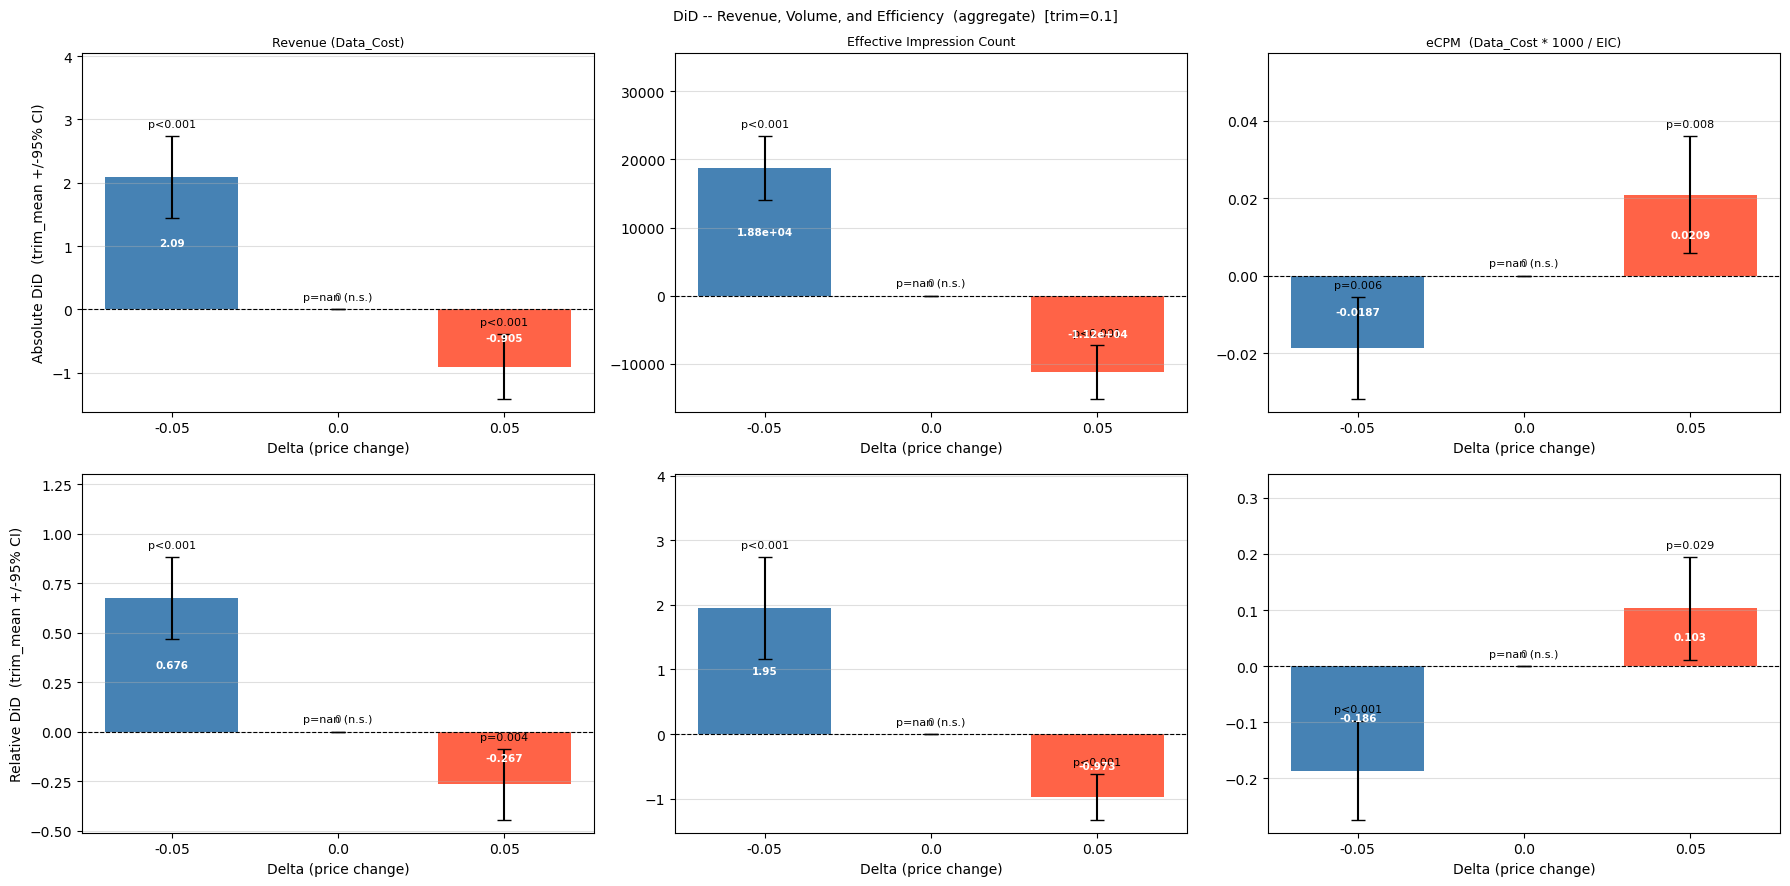

In [73]:
# ── Aggregate summary: stats tables + 2x3 chart ─────────────────────────────
# Columns: Revenue (Data_Cost) | EIC | eCPM
# Rows:    absolute DiD (top)  | relative DiD (bottom)

# All three metrics use did_vol so they share the same segments and bucket column.
# Revenue columns (did, did_rel) were merged into did_vol in the build cell above.
_all_metrics = [
    (did_vol, 'did_rev',  'did_rev_rel',  'Revenue (Data_Cost)'),
    (did_vol, 'did_eic',  'did_eic_rel',  'Effective Impression Count'),
    (did_vol, 'did_ecpm', 'did_ecpm_rel', 'eCPM  (Data_Cost * 1000 / EIC)'),
]

for df, abs_col, rel_col, name in _all_metrics:
    print(f"\n{'=' * 65}")
    print(f"  {name}")
    print(f"{'=' * 65}")
    print("  -- Absolute DiD --")
    print(desc_stats_trim(df, abs_col).to_string(index=False))
    print("\n  -- Relative DiD  (absolute DiD / ctrl pre-level) --")
    print(desc_stats_trim(df, rel_col).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col_idx, (df, abs_col, rel_col, name) in enumerate(_all_metrics):
    for row_idx, (dcol, version) in enumerate([(abs_col, 'Absolute'), (rel_col, 'Relative')]):
        ax = axes[row_idx][col_idx]
        plot_did_bars(ax, df, dcol, metric='mean', trim=_TRIM)
        ax.set_xlabel('Delta (price change)')
        if row_idx == 0:
            ax.set_title(name, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f'{version} DiD  (trim_mean +/-95% CI)')

fig.suptitle(f'DiD -- Revenue, Volume, and Efficiency  (aggregate)  [trim={_TRIM}]', fontsize=10)
plt.tight_layout()
plt.show()


## By bucket

Same DiD for impressions and eCPM broken out by revenue bucket (low / medium / high). Buckets reflect the experiment design's revenue ranking within Global sharethis segments. High-bucket segments are higher-revenue and may exhibit different price elasticity.



  Bucket: low

  -- Revenue (Data_Cost)  (n=79) --
  Absolute DiD:
 delta  n  trim_mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 20      0.103 5.605 0.400 -3.595 -0.003   0.025 0.218 1.291 0.3779  0.0310    0.1221
  0.00 38      0.000 0.000 1.000  0.000  0.000   0.000 0.000 0.000    NaN     NaN    1.0000
  0.05 19     -0.182 5.423 0.684 -4.559 -0.368  -0.003 0.057 1.191 0.3332  0.3034    0.5014
  Relative DiD:
 delta  n  trim_mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05  9     20.816 52.504 0.333  -0.538 -0.111   0.783 1.400 107.60 0.2947  0.2947    0.0977
  0.00 21      0.000  0.000 1.000   0.000  0.000   0.000 0.000   0.00    NaN     NaN    1.0000
  0.05  9    -18.933 40.355 0.667 -94.300 -4.333  -1.500 0.323   6.62 0.2211  0.2211    0.2500

  -- Effective Impression Count  (n=79) --
  Absolute DiD:
 delta  n  trim_mean      std  cdf0        p5     q25  median    q75      p95    p_t  p_trim  p_wilcox
 -0.0

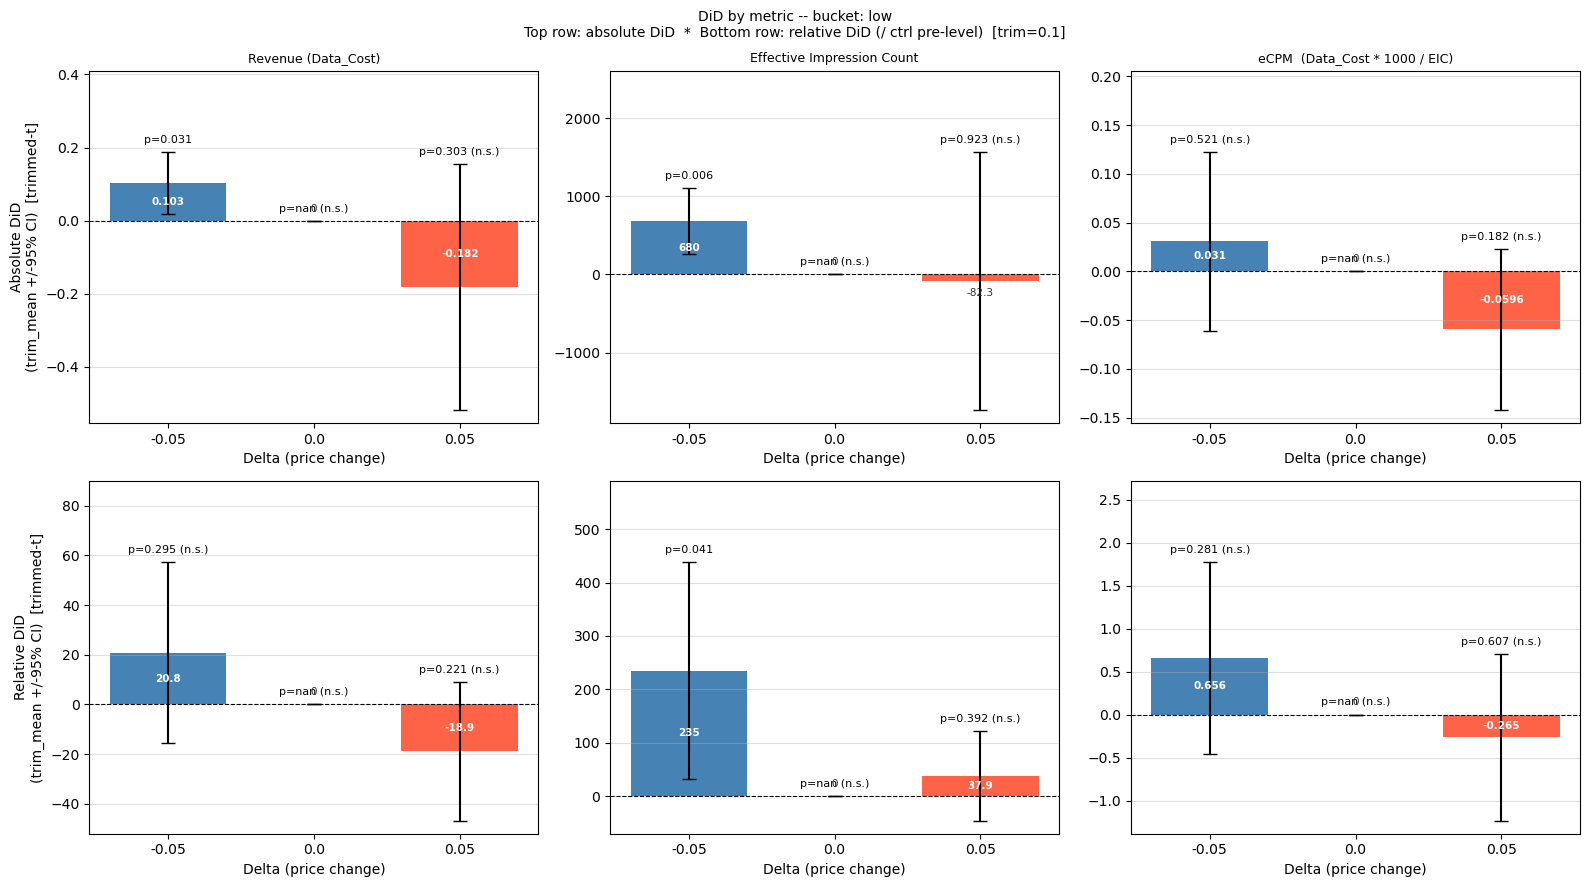

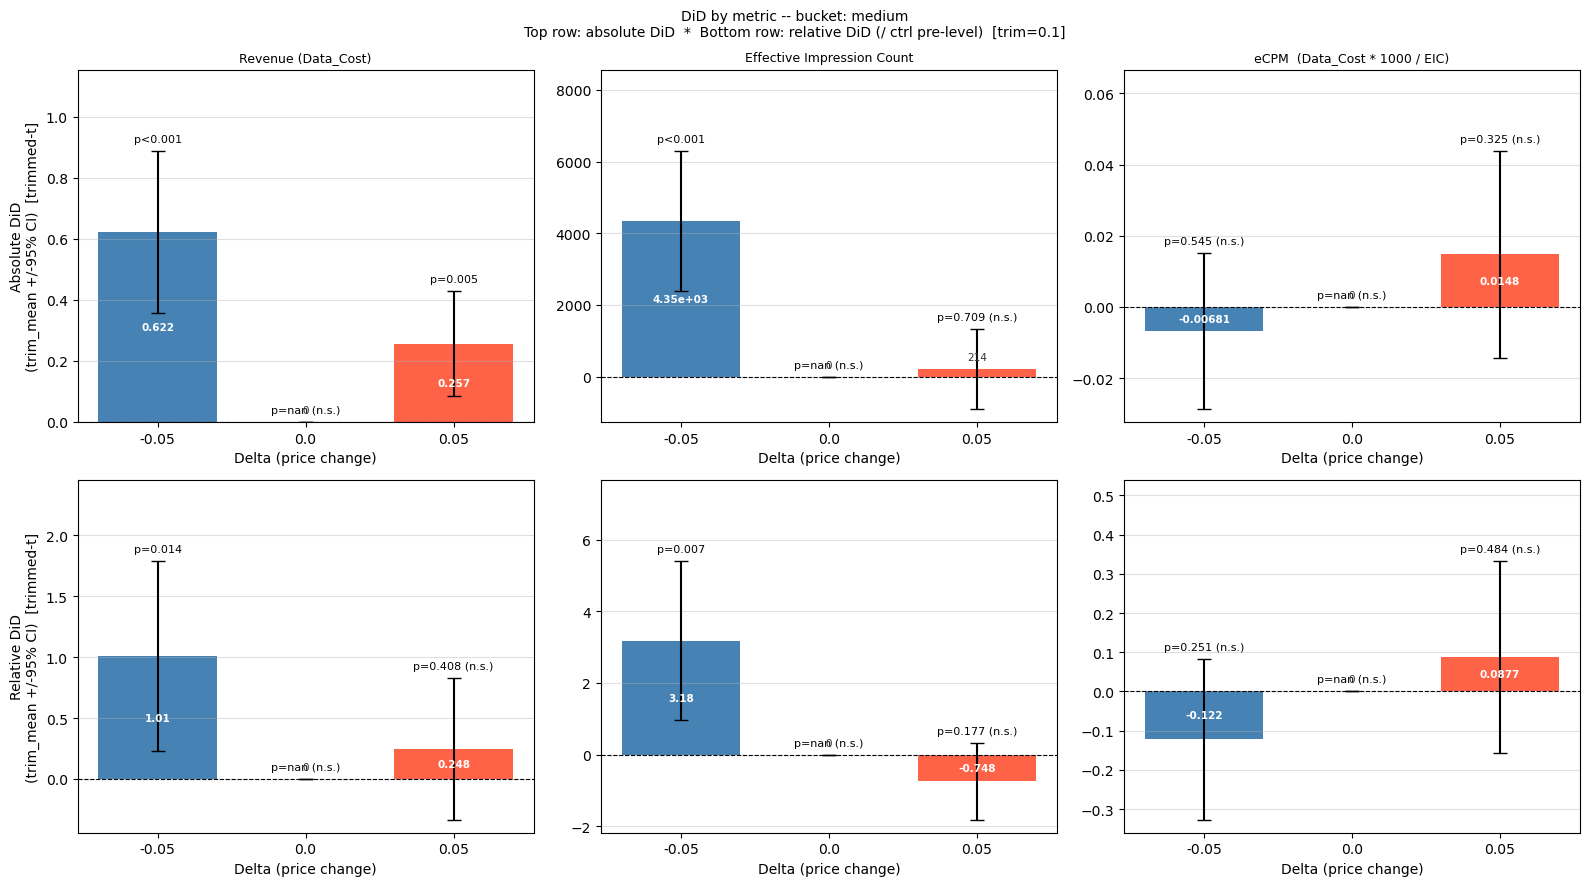

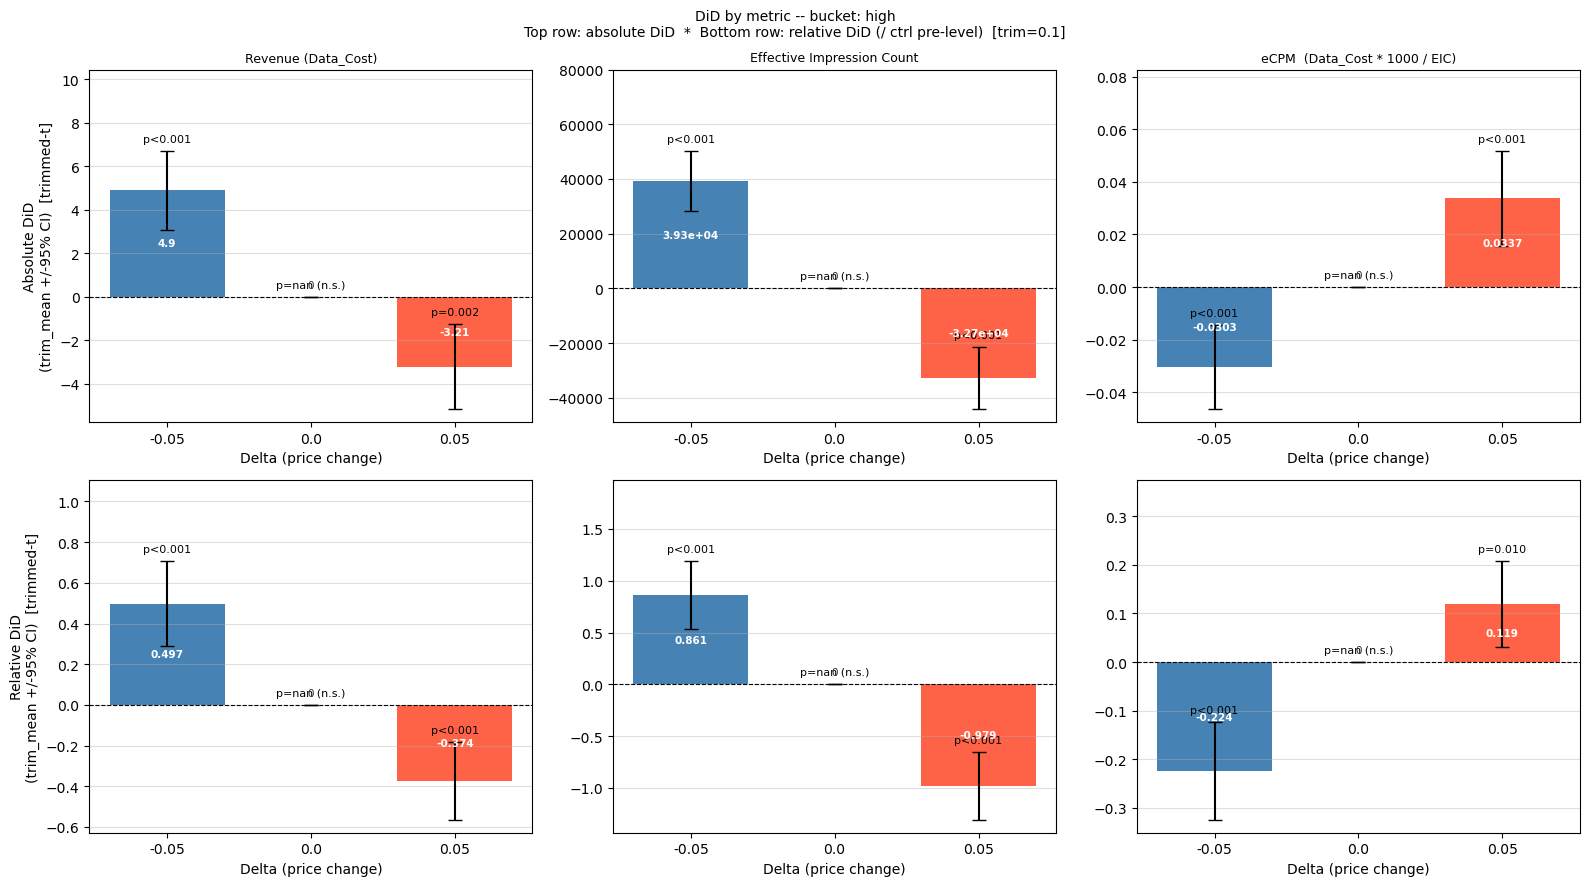

In [74]:
# ── Per-bucket stats tables ───────────────────────────────────────────────────
# `did_b` is the revenue DiD with bucket labels (defined in the earlier section).
# `did_vol` contains EIC and eCPM DiDs with bucket labels.

# All three metrics use did_vol (same segments, same bucket column).
_all_metrics_b = [
    (did_vol, 'did_rev',  'did_rev_rel',  'Revenue (Data_Cost)'),
    (did_vol, 'did_eic',  'did_eic_rel',  'Effective Impression Count'),
    (did_vol, 'did_ecpm', 'did_ecpm_rel', 'eCPM  (Data_Cost * 1000 / EIC)'),
]

for bucket in ['low', 'medium', 'high']:
    print(f"\n{'=' * 65}")
    print(f"  Bucket: {bucket}")
    print(f"{'=' * 65}")
    for df, abs_col, rel_col, name in _all_metrics_b:
        sub = df[df['bucket'] == bucket]
        print(f"\n  -- {name}  (n={len(sub)}) --")
        print("  Absolute DiD:")
        print(desc_stats_trim(sub, abs_col).to_string(index=False))
        print("  Relative DiD:")
        print(desc_stats_trim(sub, rel_col).to_string(index=False))

# ── Per-bucket charts (one 2x3 figure per bucket) ────────────────────────────
# Rows: absolute DiD (top) / relative DiD (bottom).
# Columns: Revenue | EIC | eCPM  -- side by side for direct comparison.
for bucket in ['low', 'medium', 'high']:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for col_idx, (df, abs_col, rel_col, name) in enumerate(_all_metrics_b):
        sub = df[df['bucket'] == bucket]
        for row_idx, (dcol, version) in enumerate([(abs_col, 'Absolute'), (rel_col, 'Relative')]):
            ax = axes[row_idx][col_idx]
            plot_did_bars(ax, sub, dcol, metric='mean', trim=_TRIM)
            ax.set_xlabel('Delta (price change)')
            if row_idx == 0:
                ax.set_title(name, fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f'{version} DiD\n(trim_mean +/-95% CI)  [trimmed-t]')
    fig.suptitle(
        f'DiD by metric -- bucket: {bucket}\n'
        f'Top row: absolute DiD  *  Bottom row: relative DiD (/ ctrl pre-level)  [trim={_TRIM}]',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()
